## Notes

- How to get the resolution (in time) between two adjacent reference points from the no. of reference points?
    - I think the normalized time values have no units since we do (t-min(t)) / (max(t)-min(t)) to get the normalized time. Given the set of reference time points (which are unitless), we can get the corresponding unnormalized time values those reference points correspond to. Since we are doing global normalization of times, the unnormalized time value we get will be irrespective of the light curve's observed time values.
    - Consider the following:
    ```py
    import numpy as np
    num_ref_points = 160  # hyperparameter
    min_t = 0.0  # calculated across the test dataset. This will be zero since we set first time to zero.
    max_t = 8763.17888879031  # calculated across the test dataset using the SN+AGN data (`ftransfer_ztf_2024-05-27_433174_copy`).
    t_query_points = np.linspace(0, 1., num_ref_points)
    t_query_points_unnormalized = t_query_points * (max_t-min_t) + min_t
    print(t_query_points_unnormalized)
    ```
    This gives values starting from zero and equally spaced by ~55 hrs. So if any variation in the lc is on timescales less than that, that will not be captured. This is critical for regions near the light curve peaks, since those are narrowly spread in time. Thus, using these many reference points may not capture the peaks very well, especially for fast transients. One can increase the num_ref_points as required.
    - So the answer is we cannot get the resolution just from the no. of reference points, 
- How to visualize VAE latent representations? Should we only use the mean or the entire mean + epsilon * sigma?
    - See this page: https://avandekleut.github.io/vae/ -- we should use mean + epsilon * sigma and use num_sample=1 in the code.
<!-- - We should use the decoder part of the trained model and interpolate light curves and see the interpolation performance. Perhaps that may give some hints about how is the performance and even point out to some bugs in my implementation. -->
- What value of `num_sample` to use in mTAN? Default is 10. [This line](https://github.com/reml-lab/mTAN/blob/7a3d536ee742f1cacb4a6d3478ac78a228d995ff/src/tan_interpolation.py#L97) and below use multiple values of `num_sample`'s.
- Distribution of seq_len plot: it's better if the distribution of max_seq_len doesn't have significant outliers.
<!-- - Confirm again whether I have interpreted the no. of reference points correctly: hope it's the no. of points only and not the actual time. -->
- For the cases we are manually adding using the full lcs from API, the ndethist condition may not be appropriate. Since these are full light curves, ndethist will be > 80 in non-trivial no. of cases. Instead, I think we should manually look at the light curves and select subregions ourselves, majorly around the event of interest.
    - TODO: Update with what we are doing with TDEs and CVs currently.
<!-- - **TODO: Need to also return the objIds along with dataloader -- see variable_time_collate_fn; this is where the labels are discarded, so addressing can happen there.** -->
<!-- - **TODO: To ease things, maybe it's okay to not encode the objectIds? Just use strings?** -->

**VAE**:
- https://savadikarc.github.io/post/2020/01/30/vae_vis/
- https://kvfrans.com/variational-autoencoders-explained/

**Papers using VAE**:
- https://academic.oup.com/g3journal/article/11/1/jkaa036/6105578

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set_context('talk')  # change to 'paper' later.

In [29]:
def plot_lc(
        df_alerts, name, title_suffix='', fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        sigmapsf_column='sigmapsf', finkclass_column='finkclass', objectId_column='objectId',
        figsize=(15, 6)
):
    """Plots photometry for the given name (objectId) from the alerts dataframe.

    Parameters
    ----------
    name: str
        objectID
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    fig = plt.figure(figsize=figsize)

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    for filt in np.unique(pdf[fid_column]):
        # select data from one filter at a time
        maskFilt = pdf[fid_column] == filt

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls='', marker='^', color=colordic[filt]
        )

        if finkclass_column is not None:
            _offset_x = (pdf[maskFilt][jd_column].max() - pdf[maskFilt][jd_column].min()) / 200
            _offset_y = (pdf[maskFilt][magpsf_column].max() - pdf[maskFilt][magpsf_column].min()) / 100
            for x, y, string in zip(pdf[maskFilt][jd_column], pdf[maskFilt][magpsf_column], pdf[maskFilt][finkclass_column]):
                plt.text(
                    x+_offset_x, y+_offset_y, string,
                    color=colordic[filt]
                )

    plt.gca().invert_yaxis()
    plt.legend()
    plt.title(f'{pdf[objectId_column].unique()[0]}'+': '+title_suffix)
    plt.xlabel('Modified Julian Date')
    plt.ylabel('Magnitude')
    plt.show()
    # msg = """
    # - Circles (●) with error bars show valid alerts that pass the Fink quality cuts.
    # - Upper triangles with errors (▲), represent alert measurements that do not satisfy Fink quality cuts, but are nevetheless contained in the history of valid alerts and used by classifiers.
    # - Lower triangles (▽), represent 5-sigma mag limit in difference image based on PSF-fit photometry contained in the history of valid alerts.
    # """
    # print(msg)

def plot_lc_normalized_data(observed_data, observed_mask, observed_tp, title=None):
    """Just like plot_lc() but plots normalized data (i.e., after all preprocessing on magnitudes and times), just before inputting them to the model.

    combined_data must be a tuple of (observed_data, observed_mask, time) coming from a dataloader (since it must be normalized).
    observed_data shape: [1, lc_length, dim]
    observed_mask shape: [1, lc_length, dim]
    observed_tp shape: [1, lc_length, 1]

    Below is an example code to do that:
    ```
    dim = 2
    test_loader = torch.load('test_dataloader.pth')
    batch = next(iter(test_loader))
    data = batch[0]

    # `index` below controls which image in this batch should be shown.
    index = 0
    assert index <= batch_len - 1

    batch_len = data.shape[0]
    observed_data = data[index, :, :dim].cpu().detach().numpy()
    observed_mask = data[index, :, dim:2 * dim].cpu().detach().numpy()
    observed_tp = data[index, :, -1].cpu().detach().numpy()
    ```
    """
    dim = 2
    # Replace observed values that are zero with nan since they are unobserved and must not show as zero in the plot.
    # TODO: This may not be correct since the peak of lc would then be ignored.
    observed_data[observed_data == 0] = np.nan

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    fig, ax = plt.subplots(1, 1, figsize=(15, 6))
    for i in range(dim):
        ax.plot(
            observed_tp.squeeze(), observed_data[:, i],
            ls = '', marker='o', color=colordic[i+1], label=filtdic[i+1]
        )

    ax.invert_yaxis()
    ax.legend()
    ax.set_title(f'{title}')
    ax.set_xlabel('Normalized time')
    ax.set_ylabel('Normalized magnitude')
    plt.show()

In [30]:
from constants import agn_list, stars_list, sn_list
time_in_hrs = True

In [31]:
############################################################################################
# Each row in `total_objIds` and `total_common_finkclasses` correspond to the same objectId.
############################################################################################

test_outputs_condensed = np.load('evaluate_test_outputs_condensed.npy')  # (num_test_examples, num_sample, num_ref_points, latent_dim)
total_objIds = np.load('total_objIds.npy')
# total_objIds_encoded = np.load('total_objIds_encoded.npy')
total_common_finkclasses = np.load('total_common_finkclasses.npy', allow_pickle=True)
train_objIds = np.load('train_objIds.npy')
val_objIds = np.load('val_objIds.npy')
test_objIds = np.load('evaluate_test_objIds_dataloader.npy')  # it's order matches test_outputs_condensed
test_outputs_condensed.shape, total_objIds.shape, total_common_finkclasses.shape, train_objIds.shape, val_objIds.shape, test_objIds.shape

((1752, 1, 160, 2), (8758,), (8758, 1), (5604,), (1402,), (1752,))

In [32]:
df_alerts = pd.read_parquet('alerts_processed_ftransfer_ztf_2024_05_27_433174_copy.parquet')
df_alerts.shape

(245852, 20)

In [33]:
# Read the raw alerts.
df_alerts_raw = pd.read_parquet(
    'ftransfer_ztf_2024-05-27_433174_copy/',
    columns=['objectId', 'finkclass', 'tnsclass']
)

In [34]:
objIds_custom_agn_sn = df_alerts_raw['objectId'].unique()

# Get those alerts having finkclass in agn_list and tnsclass in sn_list at the same time.
df_alerts_raw_subset = df_alerts_raw[(df_alerts_raw['finkclass'].isin(agn_list)) & (df_alerts_raw['tnsclass'].isin(sn_list))]

print(f'no. of transients in raw set of alerts = {len(objIds_custom_agn_sn)}')
# Get only those transients that are present in the final (processed) alerts dataframe since we only use those.
# objIds_custom_agn_sn = set(objIds_custom_agn_sn).intersection(df_alerts['objectId'].unique())
# print(f'no. of transients after removing those only in the raw alerts (not in the processed alerts)  = {len(objIds_custom_agn_sn)}')

objIds_custom_agn_sn_final = []
for o in df_alerts['objectId'].unique():
    # Get the most common finkclass for all alerts of the current transient.
    curr_transient_alerts = df_alerts_raw_subset[df_alerts_raw_subset['objectId'] == o]
    if (
        len(
            curr_transient_alerts[curr_transient_alerts['finkclass'].isin(agn_list)]
        ) >= 1
        and
        len(
            curr_transient_alerts[curr_transient_alerts['tnsclass'].isin(sn_list)]
        ) >= 1
    ):
        objIds_custom_agn_sn_final.append(o)

no. of transients in raw set of alerts = 40572


In [35]:
len(objIds_custom_agn_sn_final), len(objIds_custom_agn_sn)

(2, 40572)

In [36]:
del df_alerts_raw

In [37]:
test_finkclasses = []
for tobjId in test_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
    if tobjId in objIds_custom_agn_sn_final:
        test_finkclasses.append(np.array(['agn_sn']))
    else:
        test_finkclasses.append(total_common_finkclasses[idx])

test_finkclasses = np.array(test_finkclasses)

train_finkclasses = []
for tobjId in train_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
    if tobjId in objIds_custom_agn_sn_final:
        train_finkclasses.append(np.array(['agn_sn']))
    else:
        train_finkclasses.append(total_common_finkclasses[idx])

train_finkclasses = np.array(train_finkclasses)

val_finkclasses = []
for tobjId in val_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
    if tobjId in objIds_custom_agn_sn_final:
        val_finkclasses.append(np.array(['agn_sn']))
    else:
        val_finkclasses.append(total_common_finkclasses[idx])

val_finkclasses = np.array(val_finkclasses)

In [38]:
len(test_finkclasses), len(train_finkclasses), len(val_finkclasses)

(1752, 5604, 1402)

### Plot distribution of finkclasses for train, val, and test sets

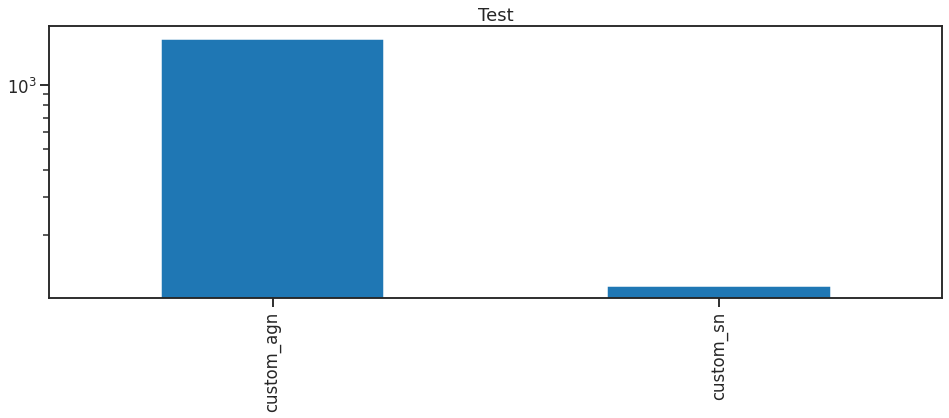

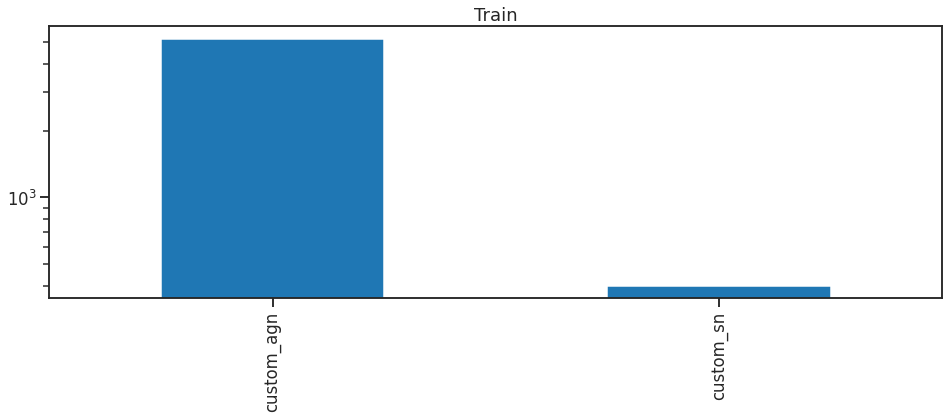

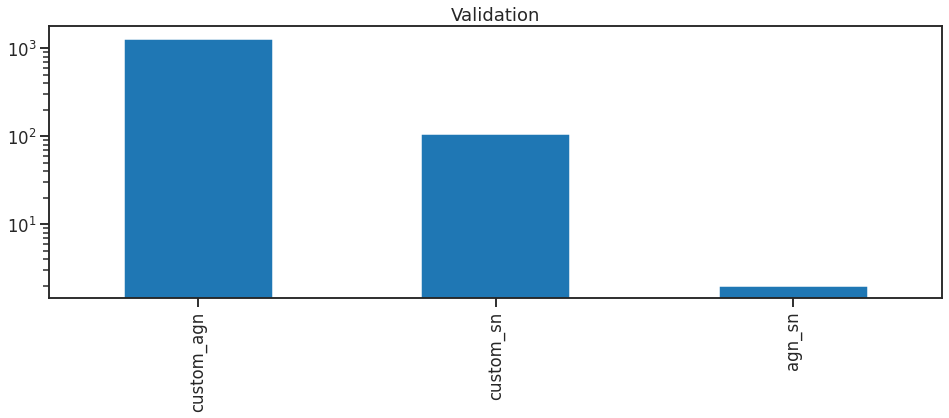

In [25]:
test_finkclasses_flatten = test_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    test_finkclasses_flatten[test_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')
ax.set_title('Test')
plt.show()

train_finkclasses_flatten = train_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    train_finkclasses_flatten[train_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')
ax.set_title('Train')
plt.show()

val_finkclasses_flatten = val_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    val_finkclasses_flatten[val_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')
ax.set_title('Validation')
plt.show()

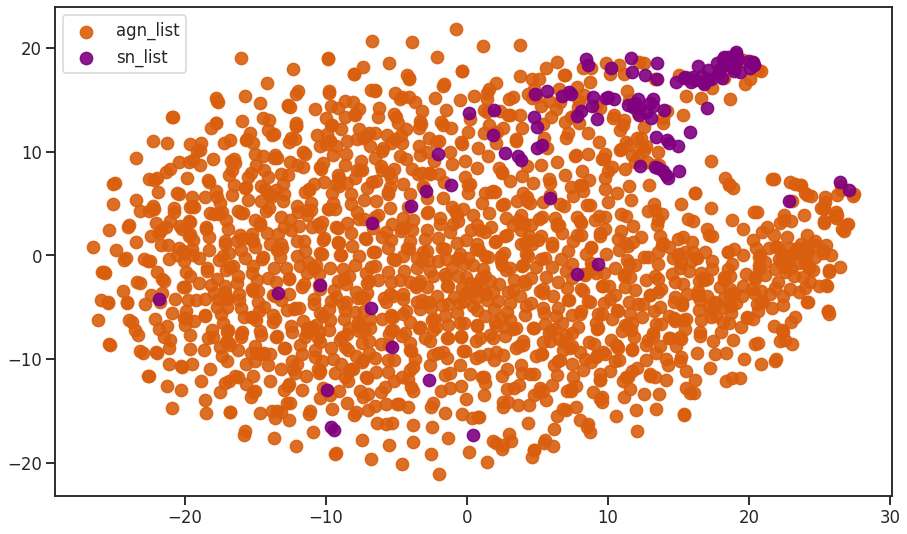

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import umap
from sklearn.manifold import TSNE

# Since test_outputs_condensed is (num_test_examples, num_sample, num_ref_points, latent_dim), we are averaging over the num_sample and num_ref_points dimensions.
test_outputs_condensed_condensed = test_outputs_condensed.mean(1).mean(2)
# test_outputs_condensed_condensed = test_outputs_condensed_condensed[:, :6]  # Because most light curves have ~<10 datapoints. See the histogram below.
# test_outputs_condensed_condensed = test_outputs_condensed[:, 0, :, :].mean(2)

# agn_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in agn_list]) > 0 else 0, 1, test_finkclasses)
# stars_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in stars_list]) > 0 else 0, 1, test_finkclasses)
# # simbad_galaxies_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in simbad_galaxies_list]) > 0 else 0, 1, test_finkclasses)
# cataclyv_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['CataclyV*']]) > 0 else 0, 1, test_finkclasses)
# tns_tde_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['TNS (TDE)']]) > 0 else 0, 1, test_finkclasses)
# sn_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in sn_list]) > 0 else 0, 1, test_finkclasses)

agn_indicator = (test_finkclasses == 'custom_agn').astype(int).squeeze()
stars_indicator = (test_finkclasses == 'custom_stars').astype(int).squeeze()
# simbad_galaxies_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in simbad_galaxies_list]) > 0 else 0, 1, test_finkclasses)
# TODO: Revise conditions for cataclyv and TDE when you decide what strings need to be used for CV and TDEs.
cataclyv_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['CataclyV*']]) > 0 else 0, 1, test_finkclasses)
tns_tde_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['TNS (TDE)']]) > 0 else 0, 1, test_finkclasses)
sn_indicator = ((test_finkclasses == 'custom_sn') | (test_finkclasses == 'Early SN Ia candidate')).astype(int).squeeze()

agn_sn_indicator = (test_finkclasses == 'agn_sn').astype(int).squeeze()  # NOTE: This will not be the same as `agn_indicator and sn_indicator`.

colors = ['#d95f0e', '#1f78b4', '#df65b0', '#33a02c', 'gray', 'purple']

pca = False
umap_use = False
tsne = True

test_outputs_condensed_condensed_scaled = StandardScaler().fit_transform(test_outputs_condensed_condensed)

if pca:
    test_outputs_condensed_condensed_transformed = PCA(n_components=2).fit_transform(test_outputs_condensed_condensed_scaled)
elif umap_use:
    test_outputs_condensed_condensed_transformed = umap.UMAP(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)
elif tsne:
    test_outputs_condensed_condensed_transformed = TSNE(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)

fig, ax = plt.subplots(1, 1, figsize=(15, 9))
if sum(agn_indicator) != 0:
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][agn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][agn_indicator==1],
        c=colors[0], label='agn_list', s=150, alpha=0.9
    )
if sum(stars_indicator) != 0:
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][stars_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][stars_indicator==1],
        c=colors[1], label='stars_list', s=150, alpha=0.9
    )

# ax.scatter(
#     test_outputs_condensed_condensed_transformed[:, 0][simbad_galaxies_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][simbad_galaxies_indicator==1],
#     c=colors[2], label='simbad_galaxies_list', s=150, alpha=0.9
# )

if sum(cataclyv_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][cataclyv_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][cataclyv_indicator==1],
        c=colors[3], label='CataclyV*', s=150, alpha=0.9
    )
if sum(tns_tde_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][tns_tde_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][tns_tde_indicator==1],
        c=colors[4], label='TNS (TDE)', s=150, alpha=0.9
    )
if sum(sn_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][sn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][sn_indicator==1],
        c=colors[5], label='sn_list', s=150, alpha=0.9
    )
if sum(agn_sn_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][agn_sn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][agn_sn_indicator==1],
        c=colors[5], label='sn_list', s=150, alpha=0.9
    )
ax.legend()

For the above plots, we have compressed the encoded representations across the num_sample and filter dimensions. Here num_sample=1, so nothing significant. When we compress the representations across the filter dimension, note that taking the mean or the median will be the same since we have only 2 filters. Even after taking the mean (or even median since they are the same here), it will still capture the relative evolution of the g and r bands (for e.g., if one band is decaying more rapidly than the other, that will still be captured).

Now we plot lcs at three regions in the projection space: bottom-left, top-right, and somewhat middle.

For SN

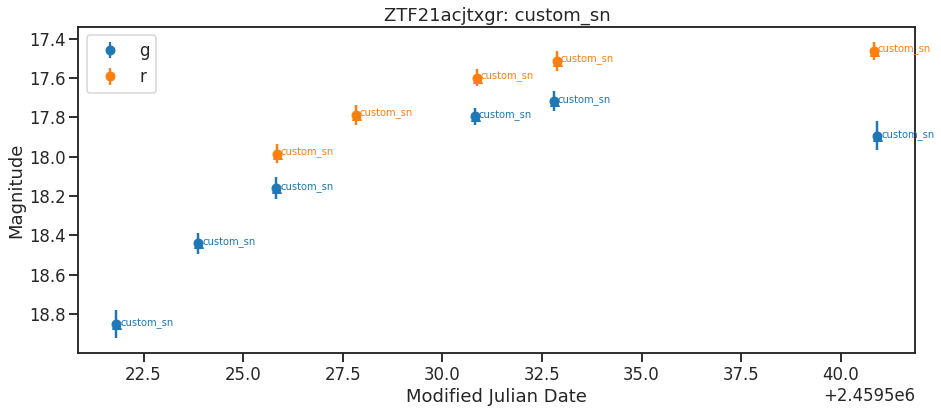

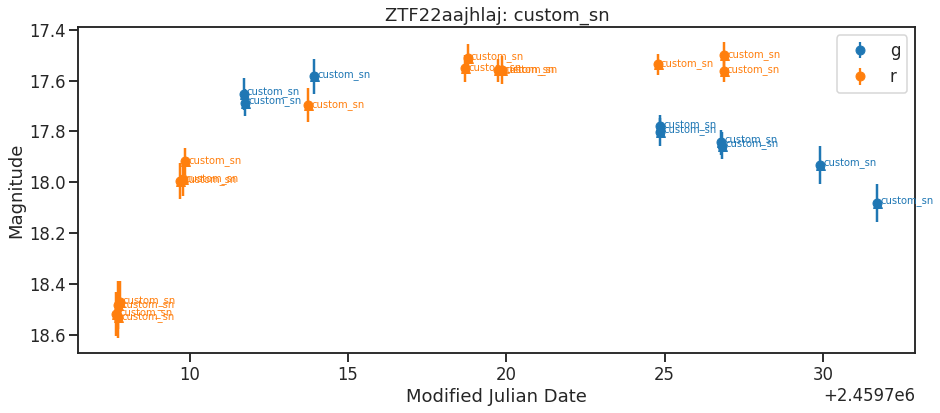

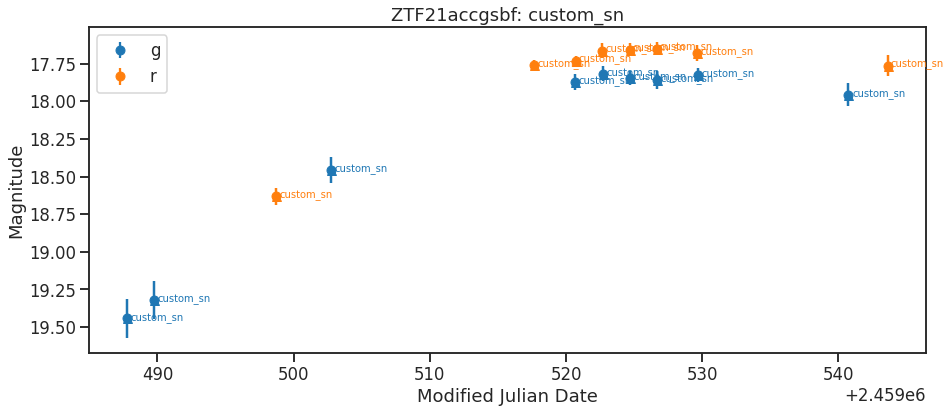

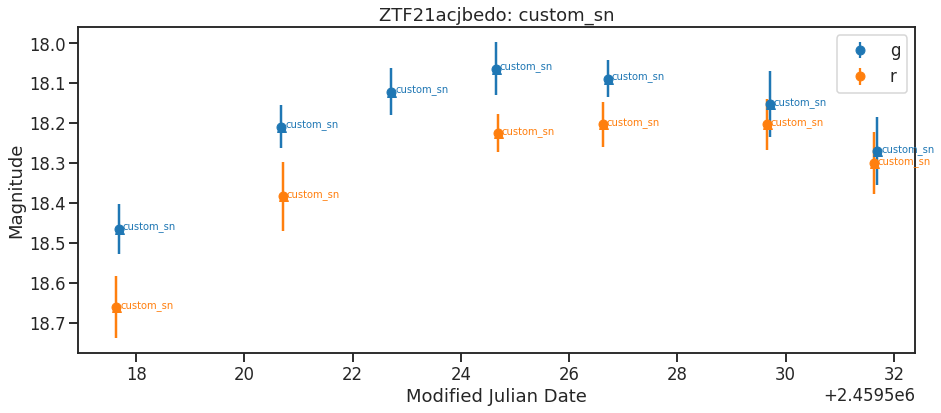

In [12]:
# bottom-left (SN)
extreme_sn_indices = np.where(((test_outputs_condensed_condensed_transformed[:, 0] < -10) & (test_outputs_condensed_condensed_transformed[:, 1] < -10) & (sn_indicator == 1)))[0]
for eidx in extreme_sn_indices:
    currObjId = test_objIds[eidx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))

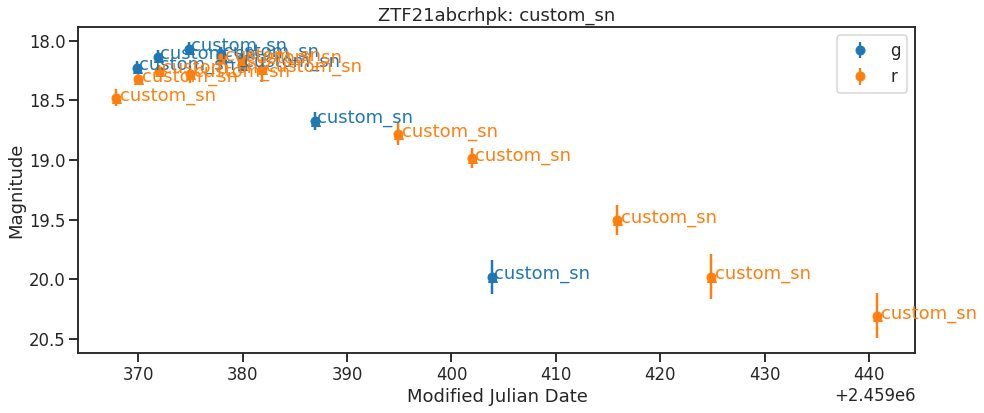

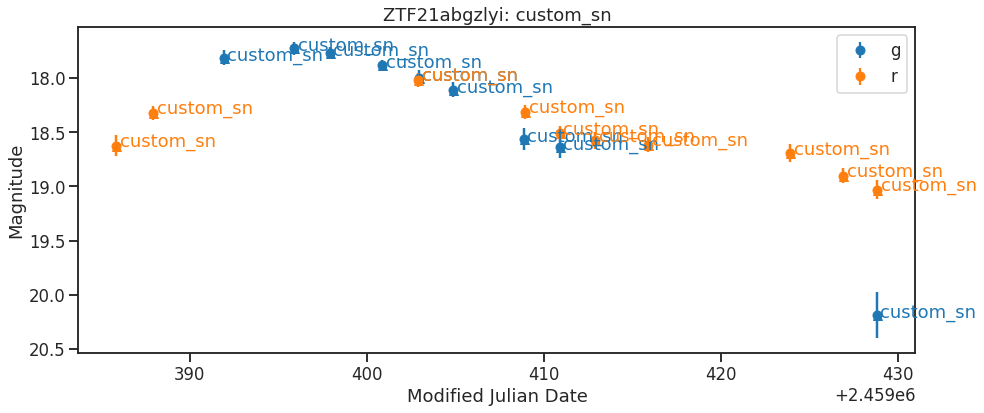

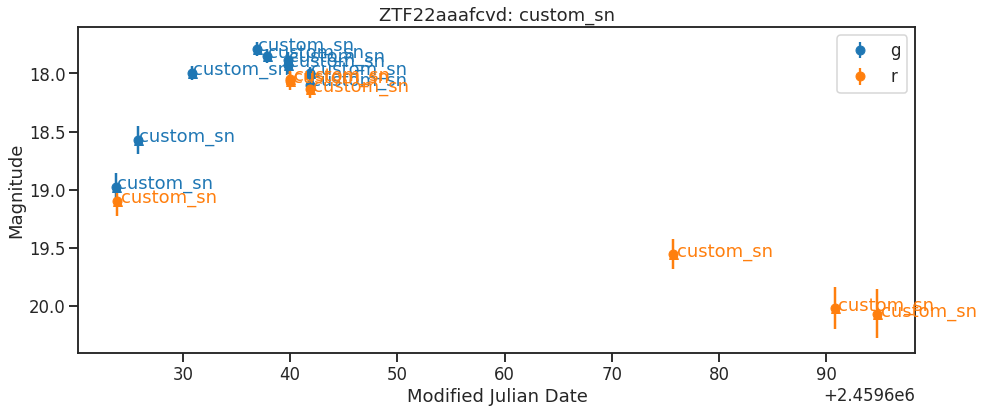

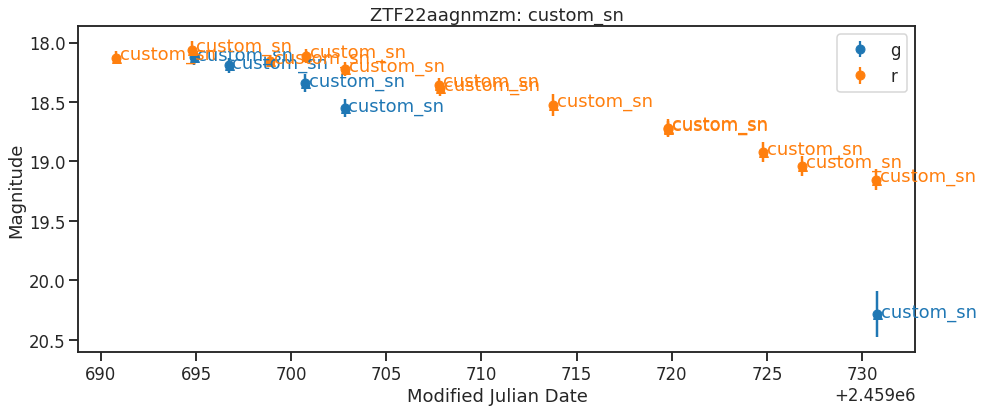

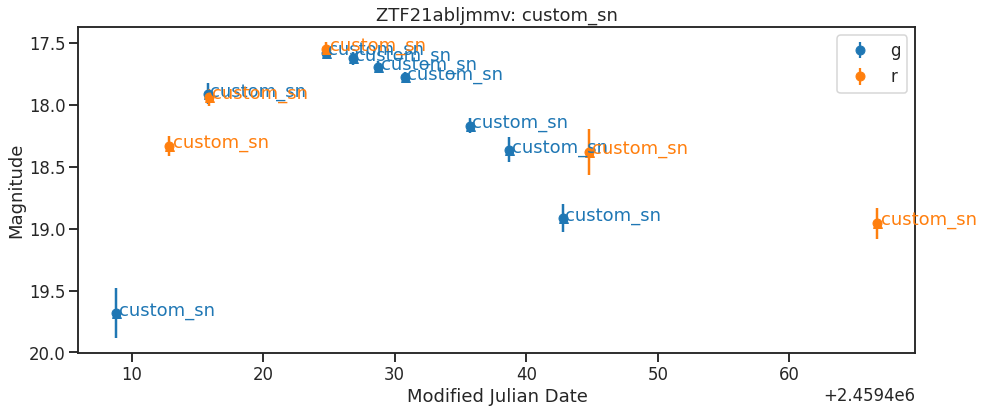

...

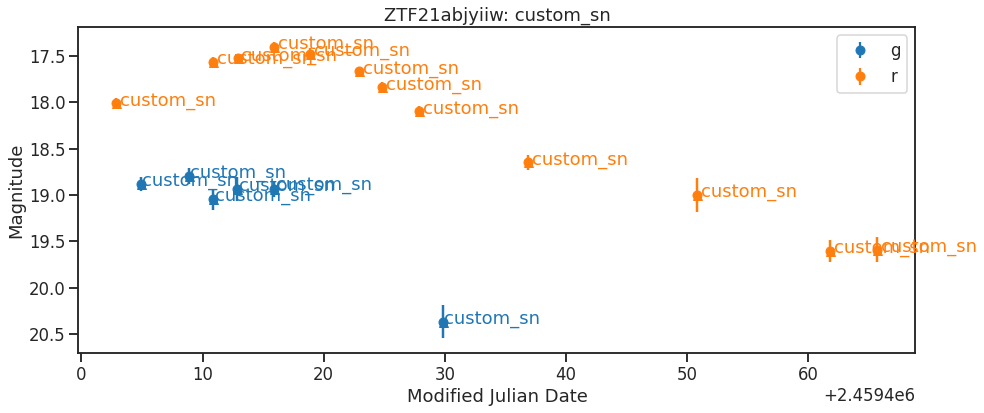

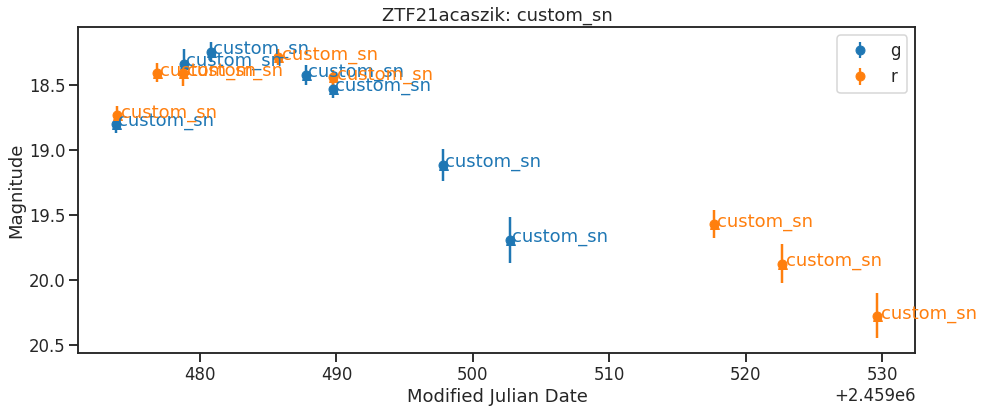

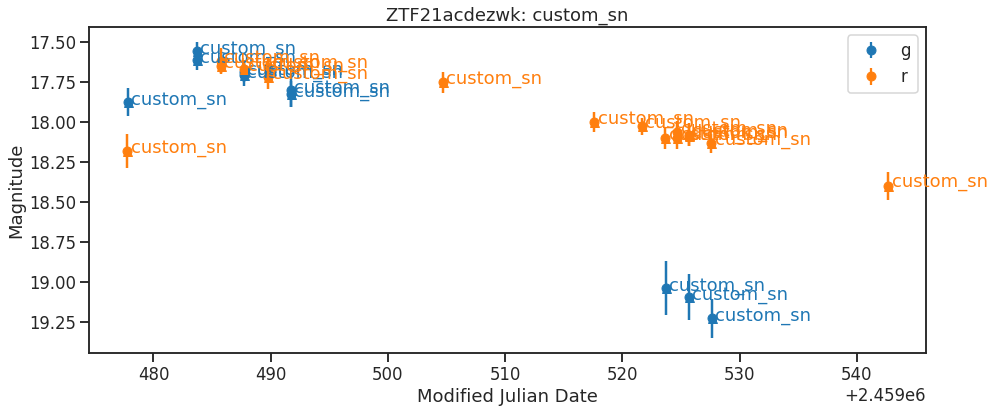

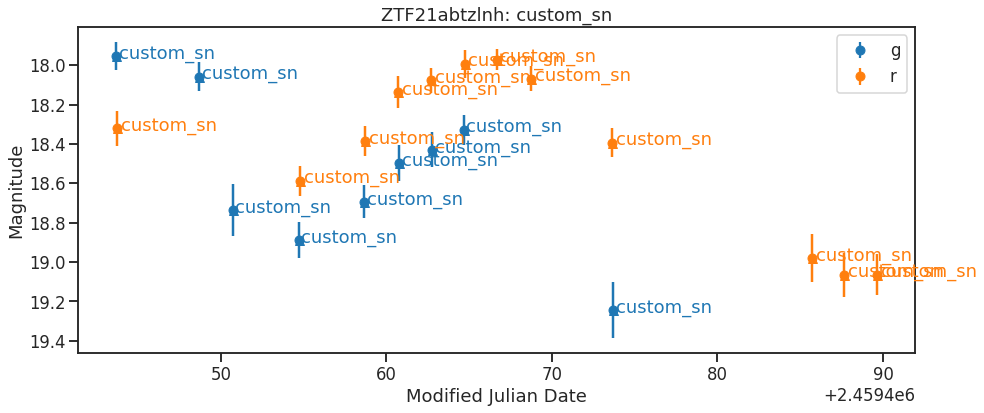

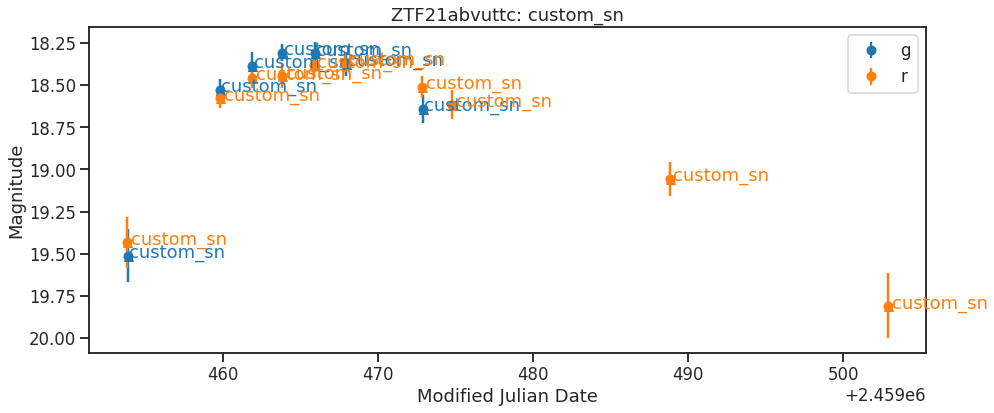

In [41]:
# top-right (SN)
extreme_sn_indices = np.where(((test_outputs_condensed_condensed_transformed[:, 0] > 10) & (test_outputs_condensed_condensed_transformed[:, 1] > 15) & (sn_indicator == 1)))[0]
for counter, eidx in enumerate(extreme_sn_indices):
    currObjId = test_objIds[eidx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    if counter == 10:
        break

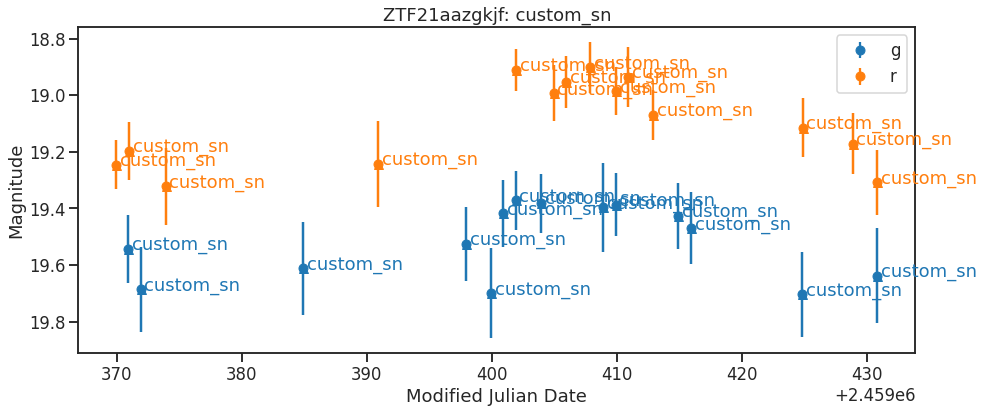

In [34]:
# middle (along the line joining bottom-left to top-right; SN)
extreme_sn_indices = np.where(((test_outputs_condensed_condensed_transformed[:, 0] > -5) & (test_outputs_condensed_condensed_transformed[:, 0] < 5) & (test_outputs_condensed_condensed_transformed[:, 1] > -5) & (test_outputs_condensed_condensed_transformed[:, 1] < 5) & (sn_indicator == 1)))[0]
for counter, eidx in enumerate(extreme_sn_indices):
    currObjId = test_objIds[eidx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    if counter == 10:
        break

For AGN

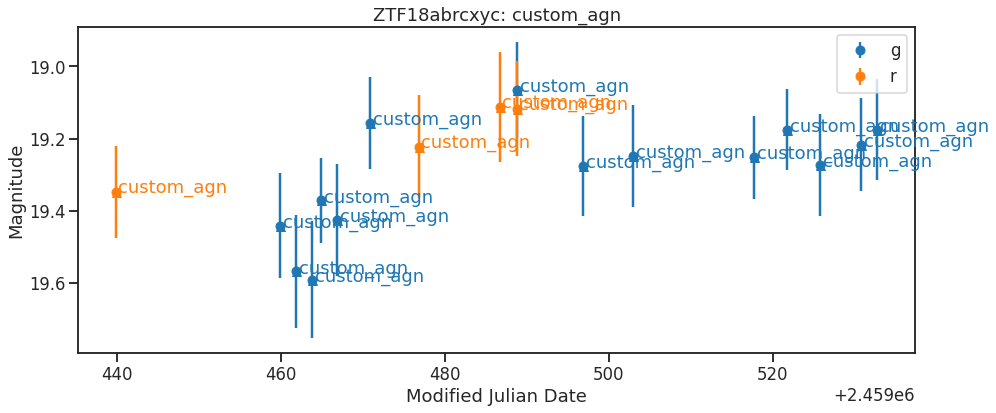

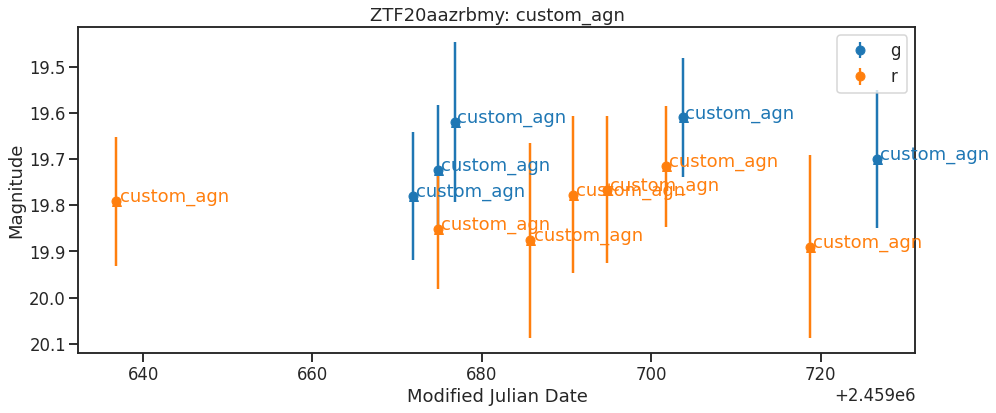

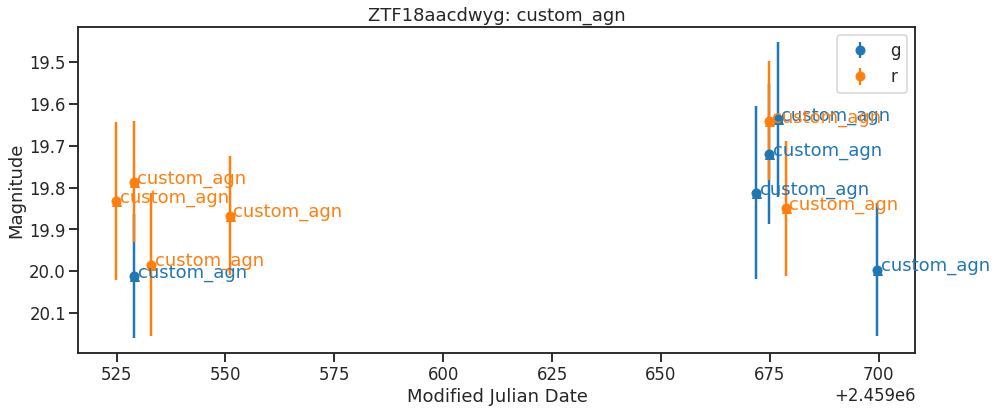

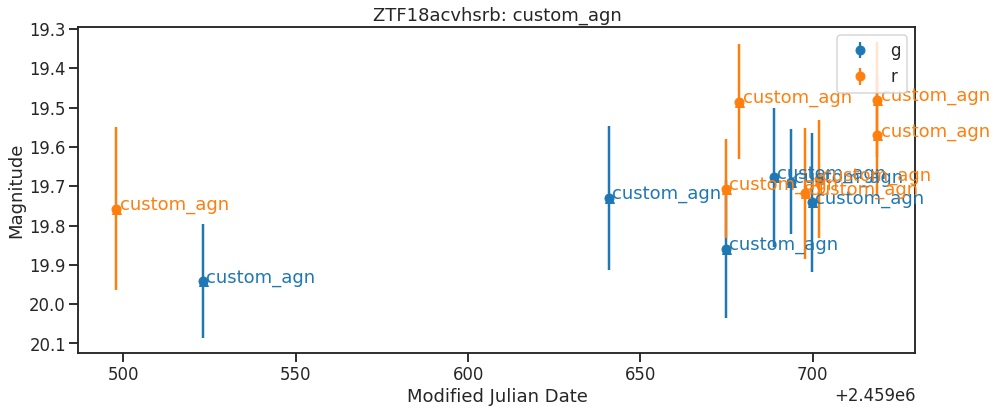

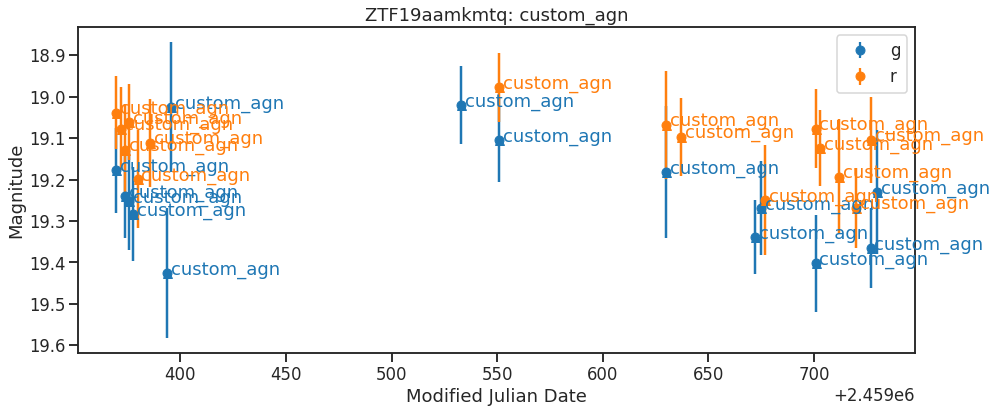

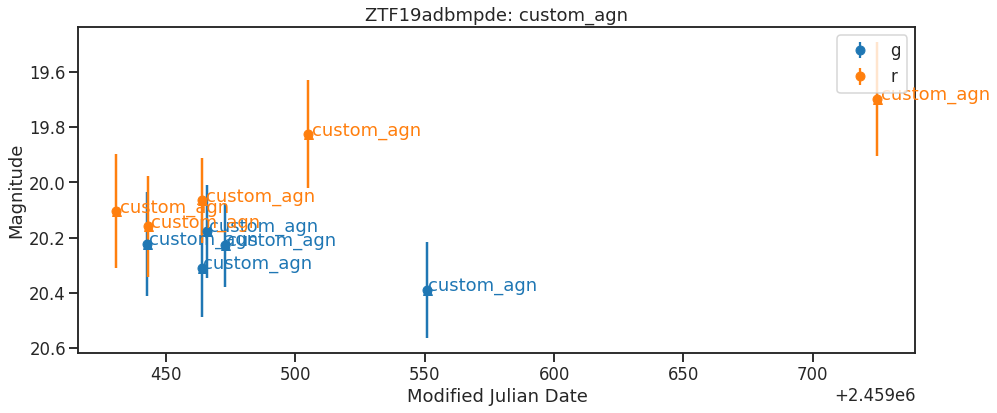

In [37]:
# bottom-left (AGN)
extreme_agn_indices = np.where(((test_outputs_condensed_condensed_transformed[:, 0] < -5) & (test_outputs_condensed_condensed_transformed[:, 1] < -5) & (agn_indicator == 1)))[0]
for counter, eidx in enumerate(extreme_agn_indices):
    currObjId = test_objIds[eidx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    if counter == 5:
        break

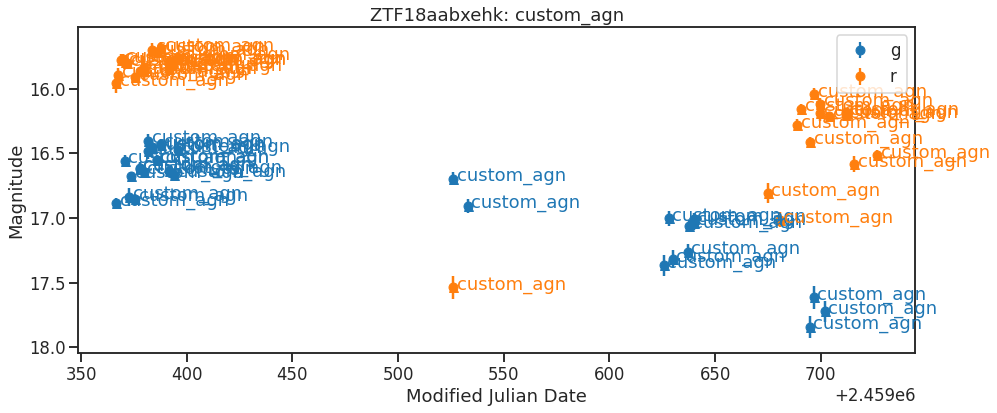

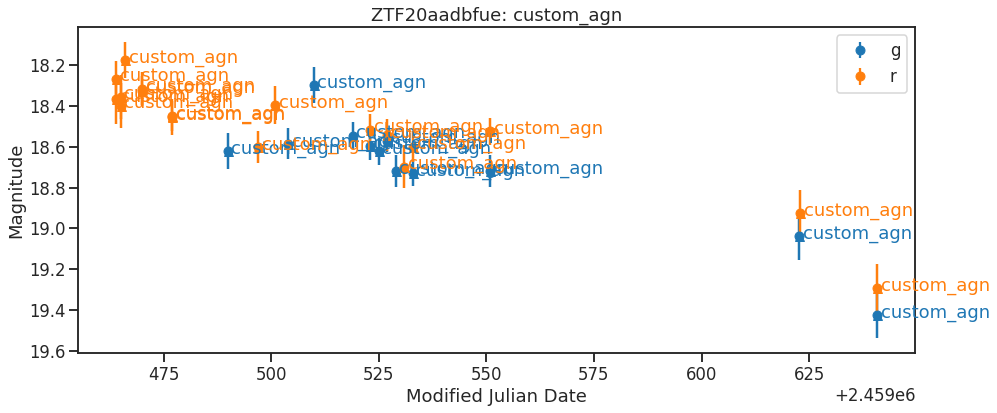

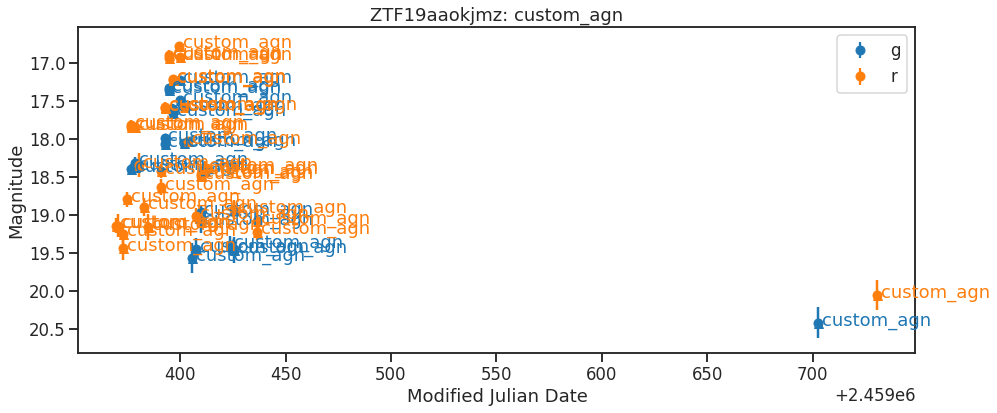

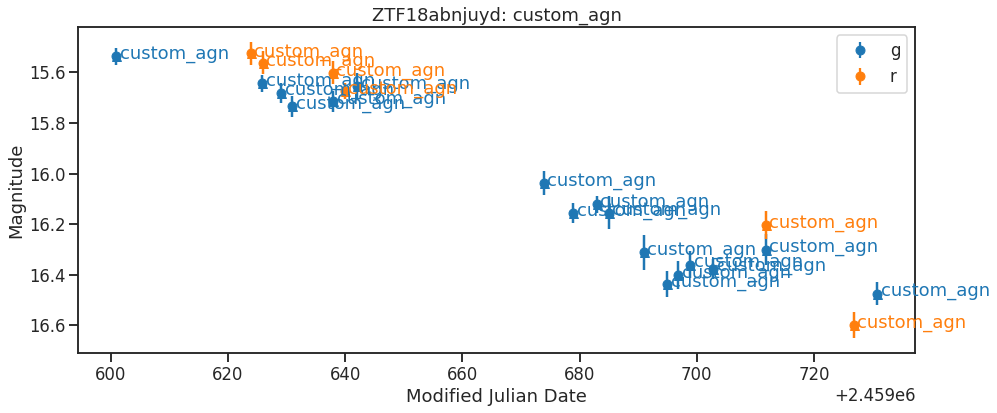

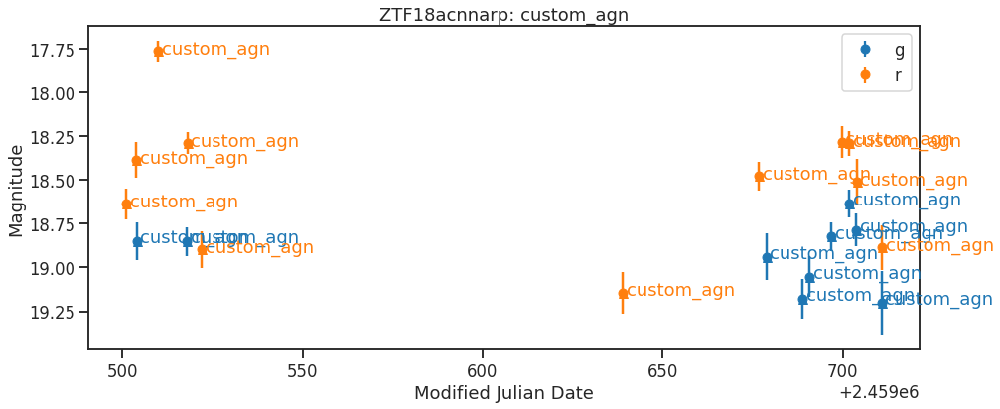

...

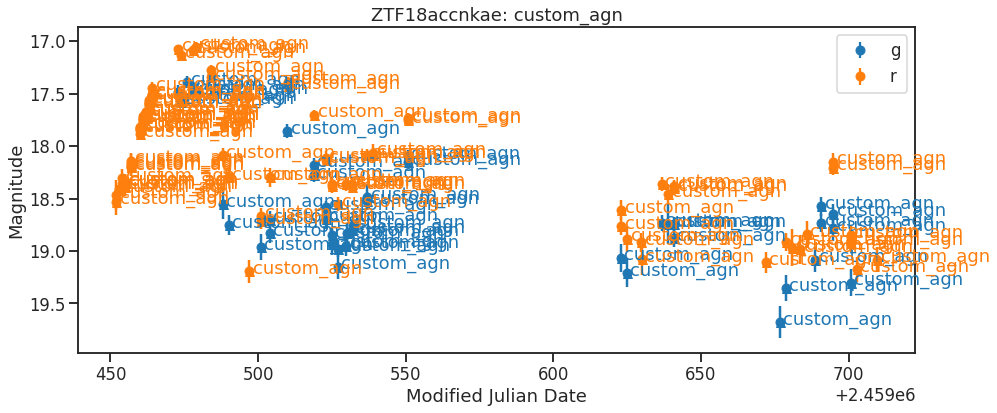

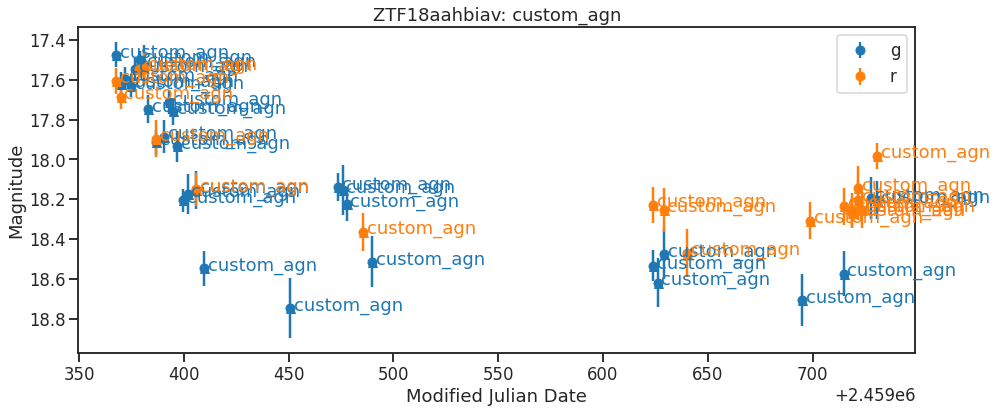

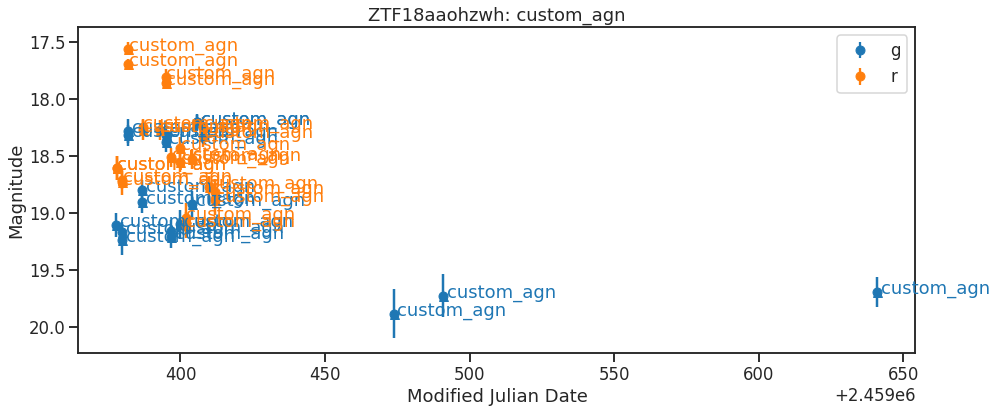

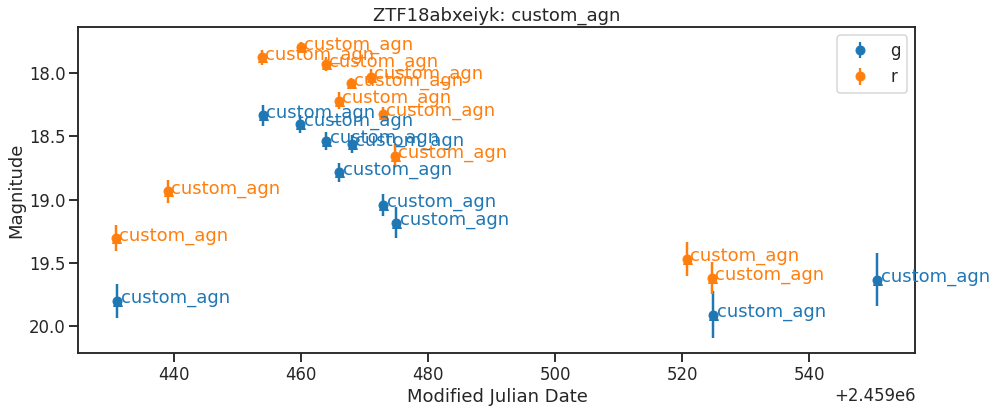

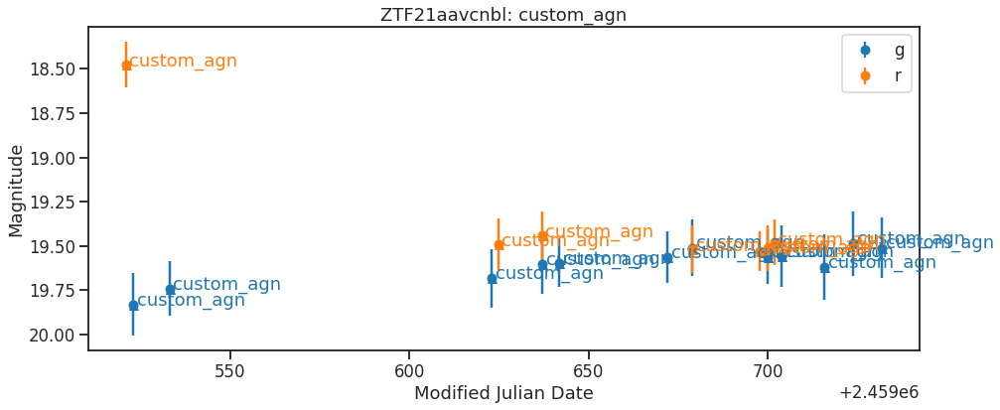

In [40]:
# top-right (AGN)
extreme_agn_indices = np.where(((test_outputs_condensed_condensed_transformed[:, 0] > 10) & (test_outputs_condensed_condensed_transformed[:, 1] > 15) & (agn_indicator == 1)))[0]
for counter, eidx in enumerate(extreme_agn_indices):
    currObjId = test_objIds[eidx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    if counter == 10:
        break

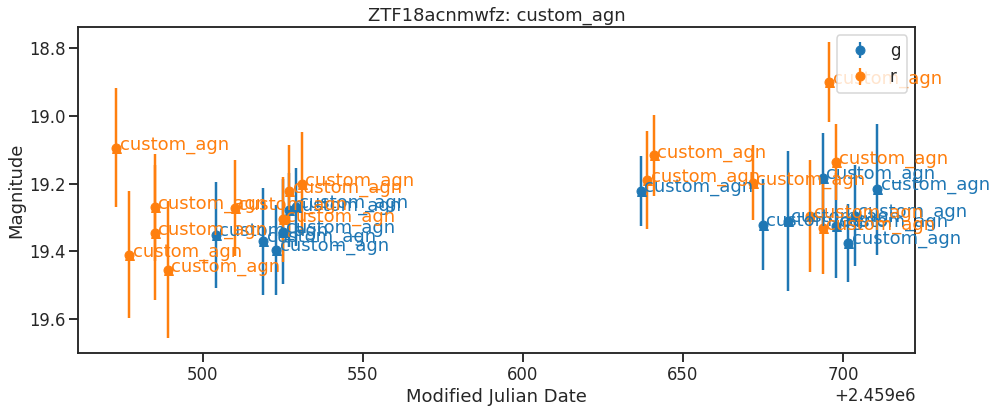

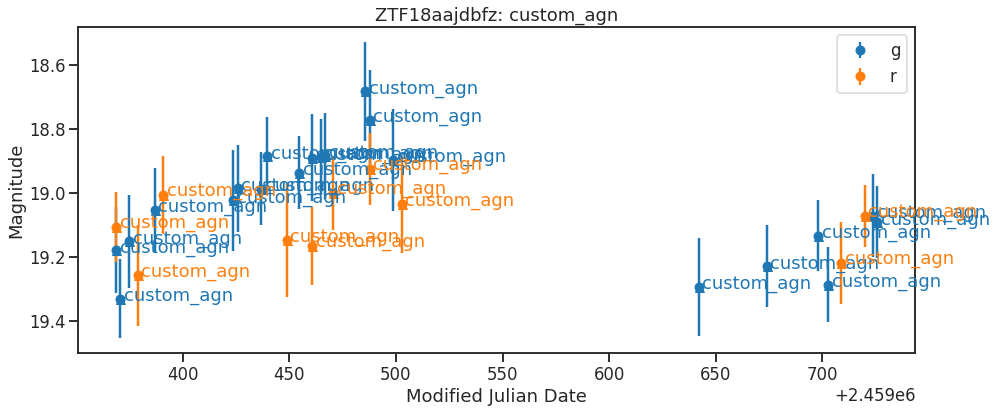

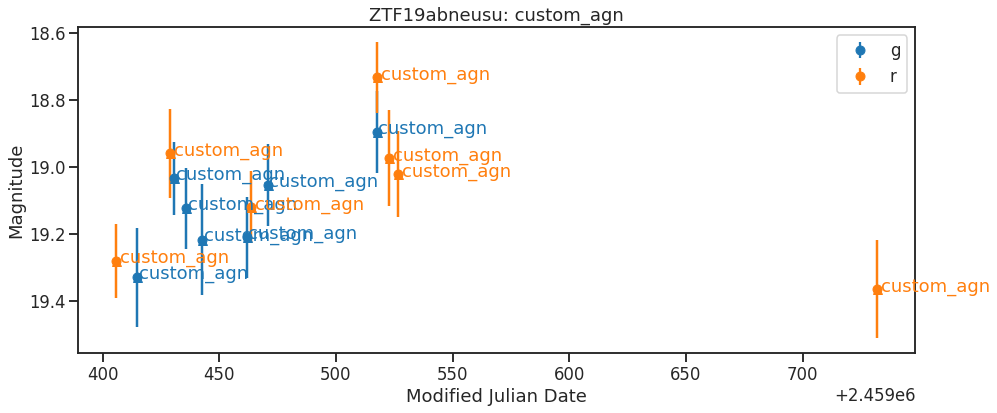

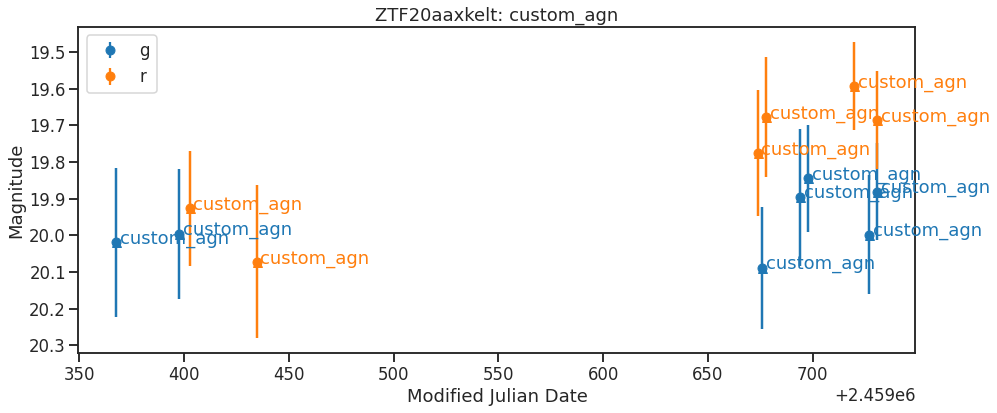

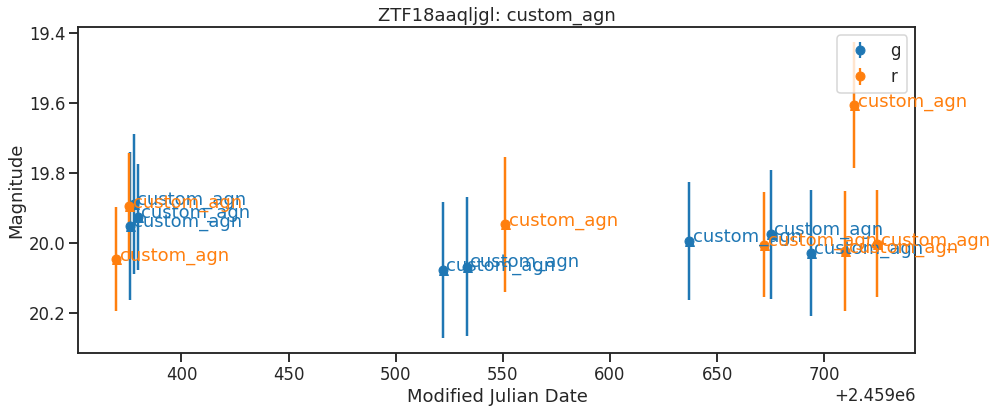

...

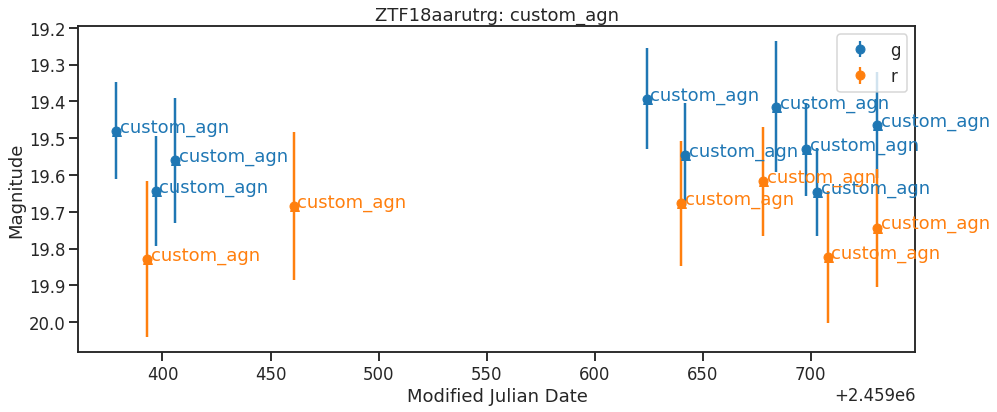

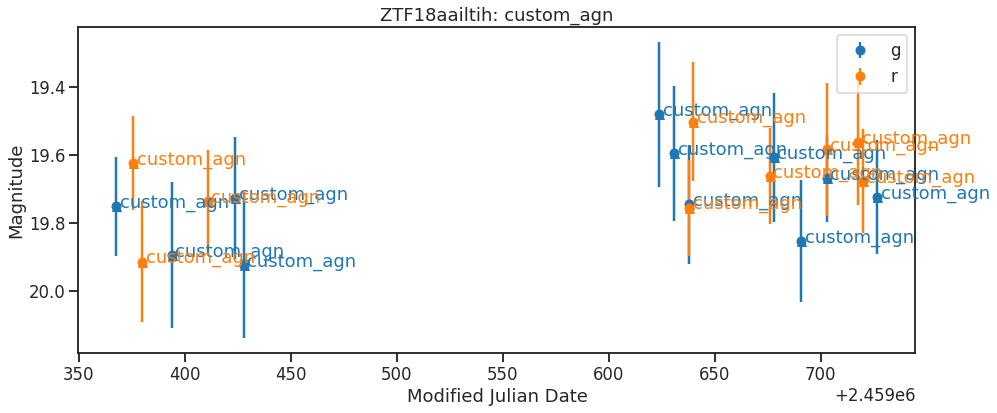

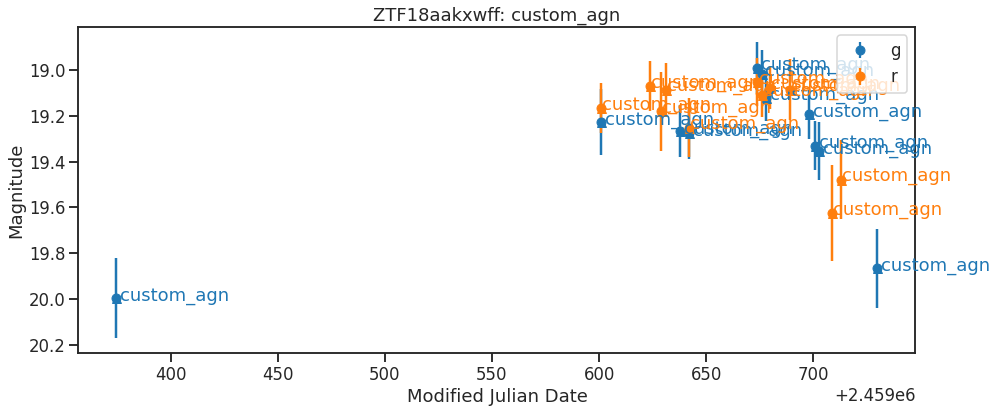

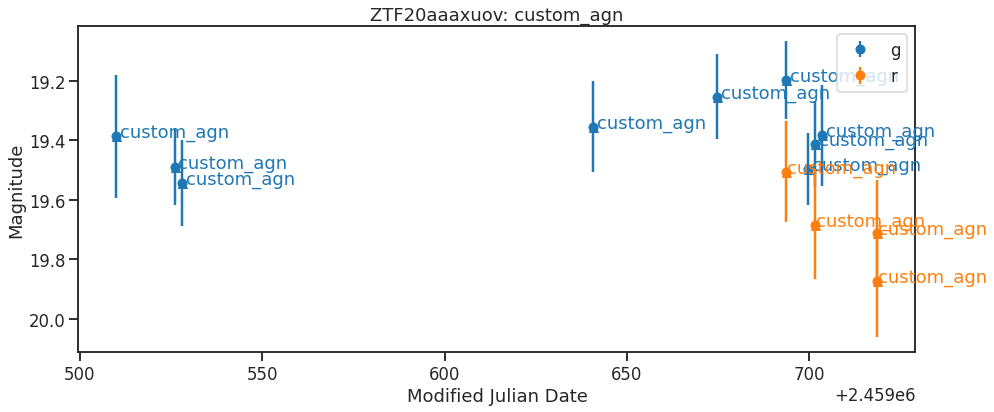

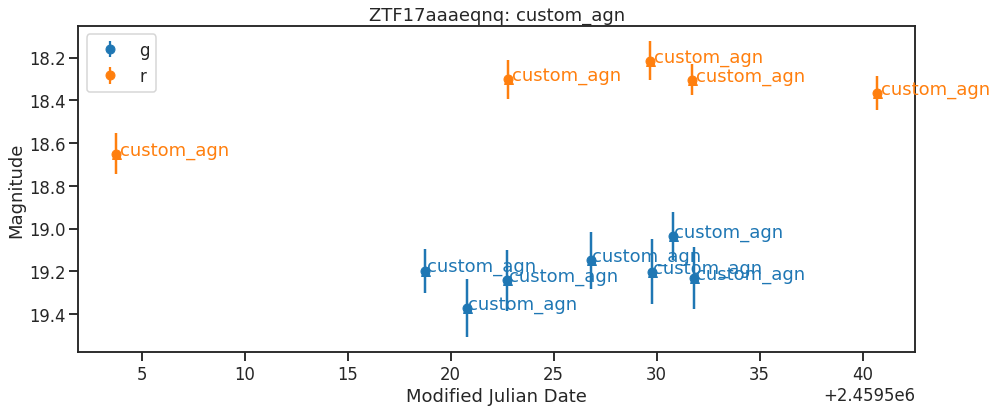

In [42]:
# middle (along the line joining bottom-left to top-right; SN)
extreme_agn_indices = np.where(((test_outputs_condensed_condensed_transformed[:, 0] > -5) & (test_outputs_condensed_condensed_transformed[:, 0] < 5) & (test_outputs_condensed_condensed_transformed[:, 1] > -5) & (test_outputs_condensed_condensed_transformed[:, 1] < 5) & (agn_indicator == 1)))[0]
for counter, eidx in enumerate(extreme_agn_indices):
    currObjId = test_objIds[eidx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    if counter == 10:
        break

Out of curiosity, we now visualize AGN lcs at the middle-right and bottom-left of the projection space. bottom-left AGN lcs were already shown above, here we plot the middle-right lcs. Because if you see the projection plot colored with time of peak since lc start, you see middle-right lcs have the highest time of peak since lc start which indicates those are rising until the end of lc. But above (at least based on SN lcs) we observed bottom-left lcs are also rising. So we want to see what differences exist between AGN lcs at these two locations. Is there any noticeable difference? Intuitively, there should be some difference since they are located at two different locations in the projection space.

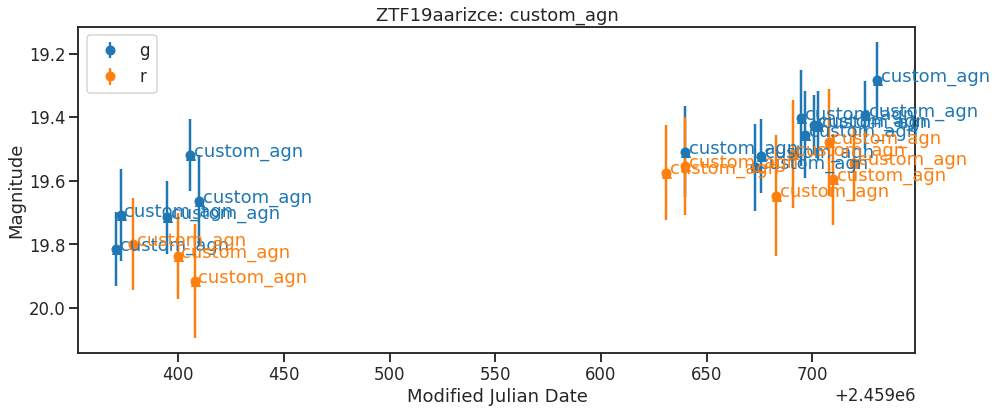

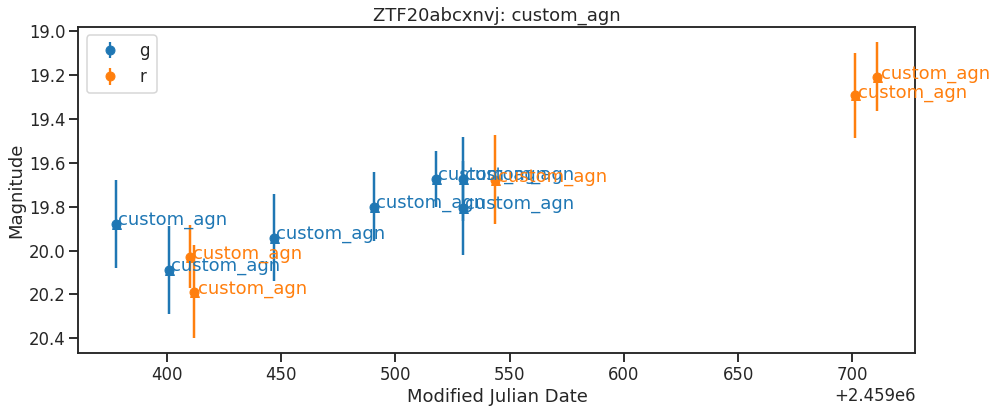

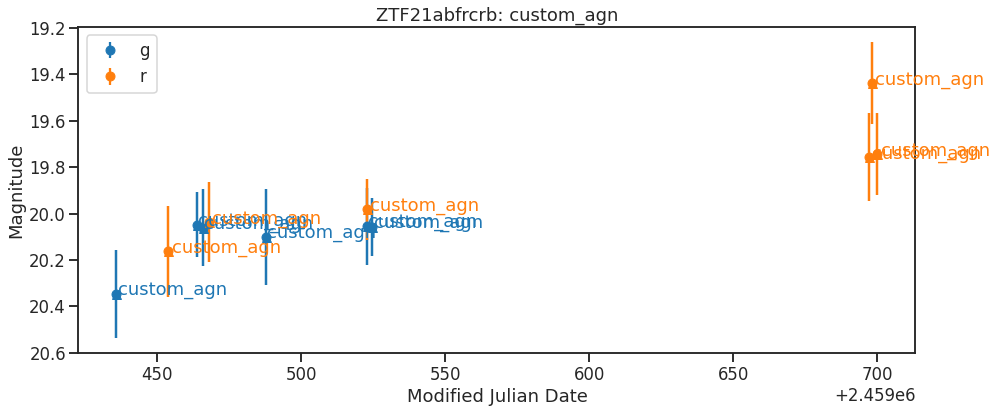

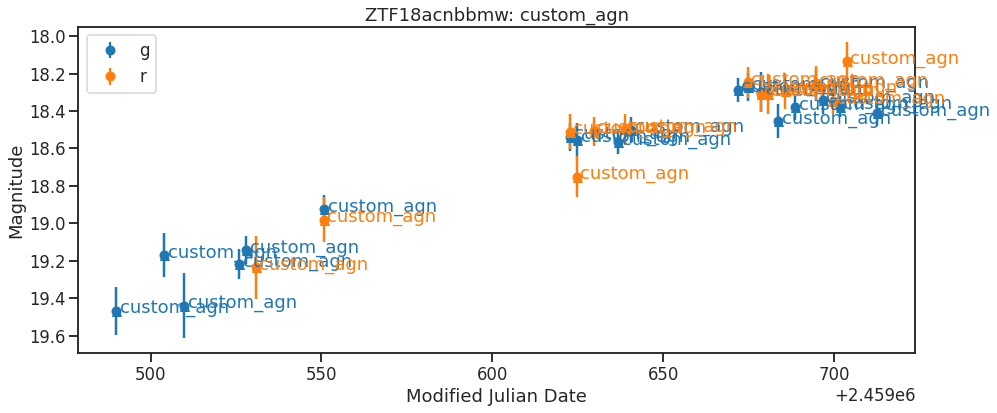

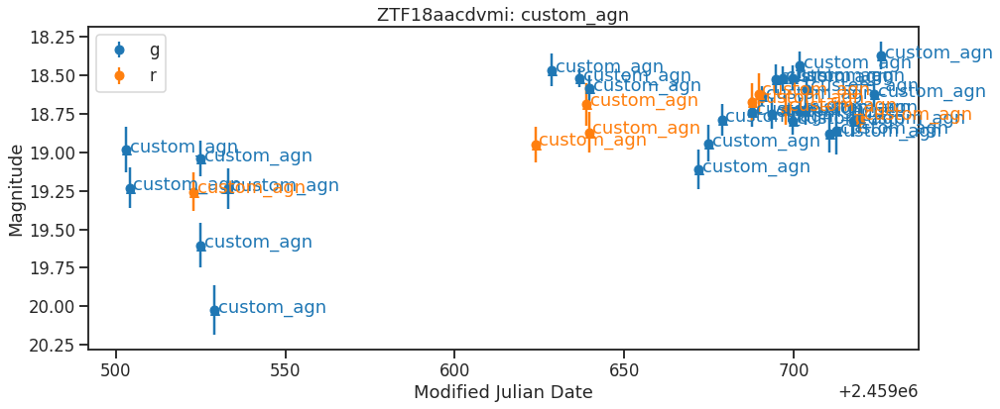

...

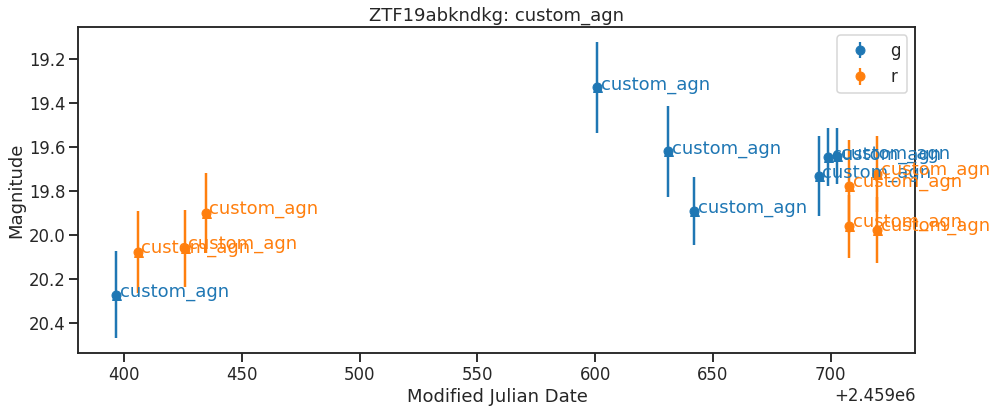

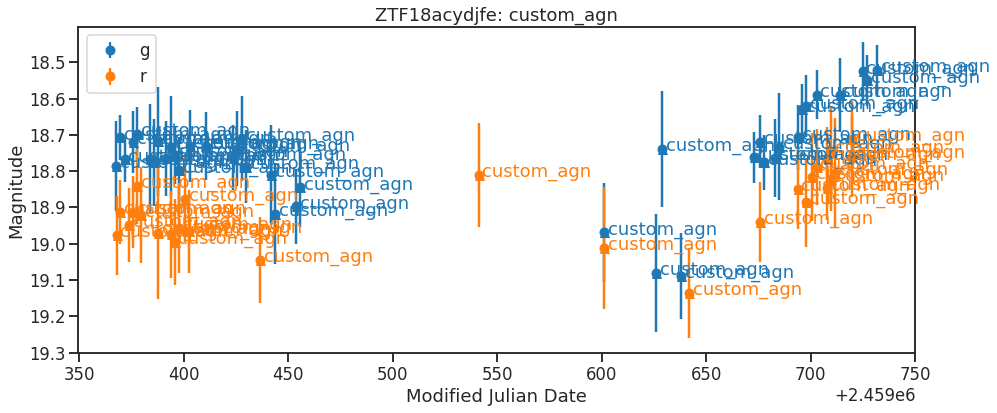

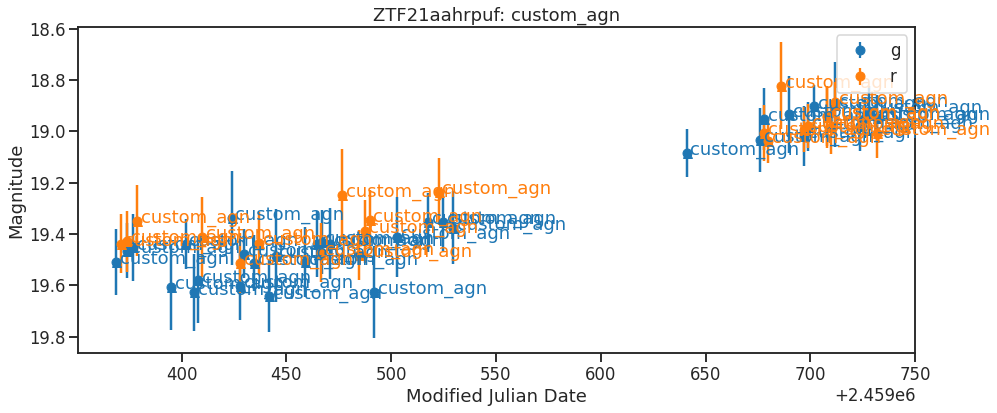

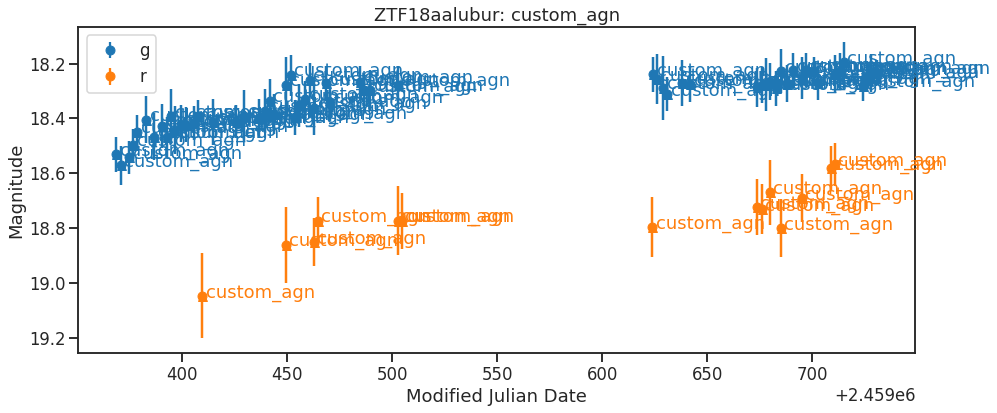

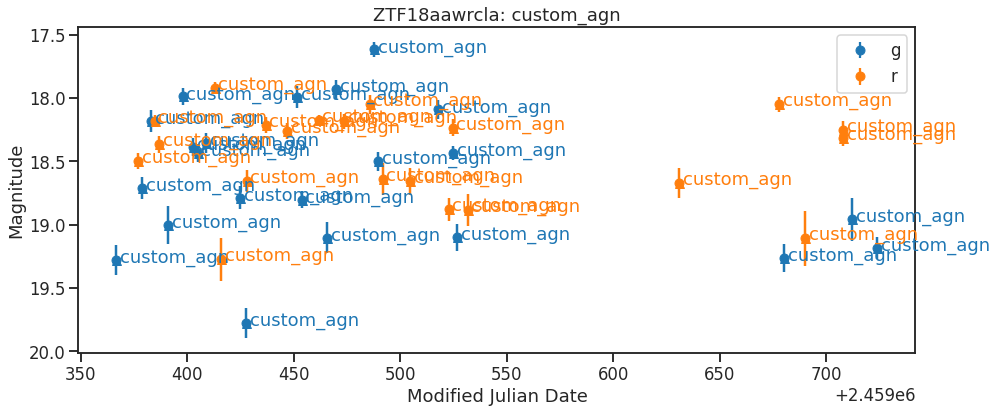

In [35]:
# middle-right (AGN)
extreme_agn_indices = np.where(((test_outputs_condensed_condensed_transformed[:, 0] > 10) & (test_outputs_condensed_condensed_transformed[:, 1] > -7) & (test_outputs_condensed_condensed_transformed[:, 1] < 7) & (agn_indicator == 1)))[0]
for counter, eidx in enumerate(extreme_agn_indices):
    currObjId = test_objIds[eidx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    if counter == 10:
        break

TODO: What differences do we find in the lcs from the above two cells?

In [27]:
# fig, ax = plt.subplots(1, 1, figsize=(20, 5))
# for i in range(len(test_outputs_condensed_condensed)):
#     ax.plot(test_outputs_condensed_condensed[i, :])
#     if i == 5:
#         break

Text(0.5, 1.0, 'total_common_finkclasses')

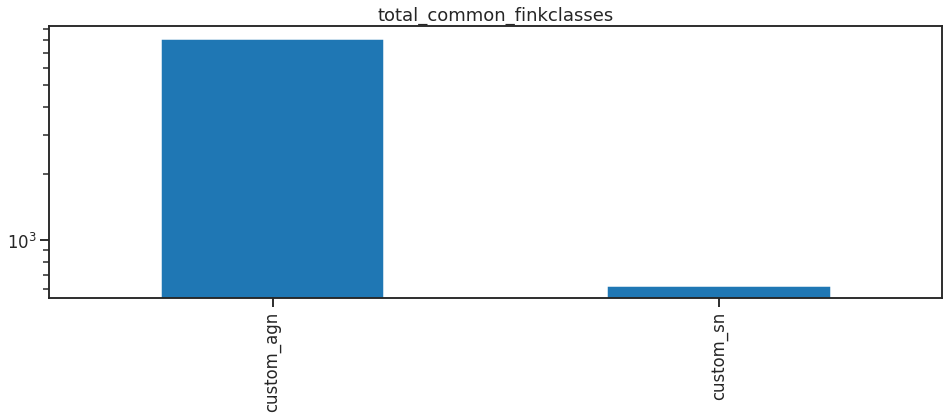

In [10]:
# Plots the distribution of finkclasses across the entire dataset (train+val+test).
total_common_finkclasses_flatten = total_common_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    total_common_finkclasses_flatten[total_common_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')
ax.set_title('total_common_finkclasses')

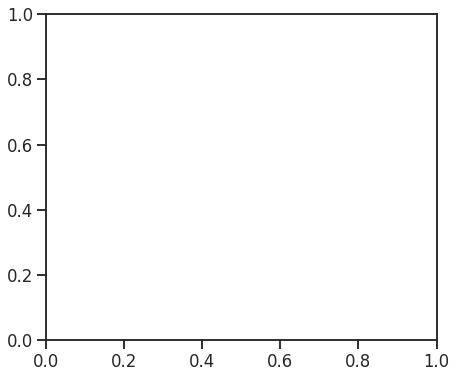

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

if sum(cataclyv_indicator != 0):  # Because of there are no examples, then no point in plotting these binary class plots.
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][cataclyv_indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][cataclyv_indicator == 0],
        c='black', alpha=0.5
    )

    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][cataclyv_indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][cataclyv_indicator == 1],
        c='#cc4c02', s=150, alpha=0.5
    )

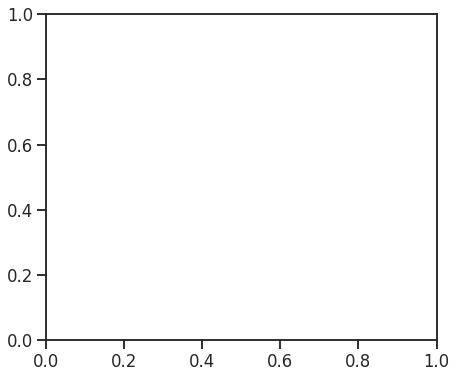

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

if sum(stars_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][stars_indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][stars_indicator == 0],
        c='black', alpha=0.5
    )

    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][stars_indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][stars_indicator == 1],
        c='#cc4c02', s=150, alpha=0.5
    )

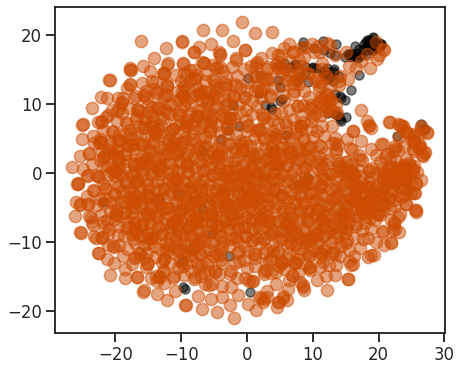

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
if sum(agn_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][agn_indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][agn_indicator == 0],
        c='black', alpha=0.5
    )

    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][agn_indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][agn_indicator == 1],
        c='#cc4c02', s=150, alpha=0.5
    )

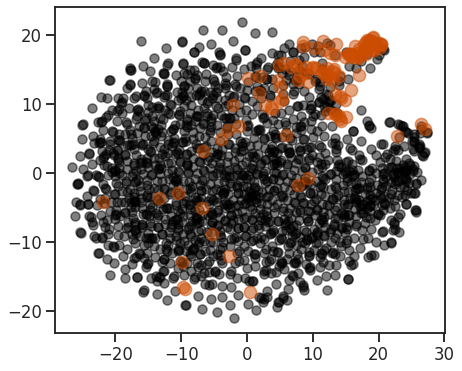

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

if sum(sn_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][sn_indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][sn_indicator == 0],
        c='black', alpha=0.5
    )

    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][sn_indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][sn_indicator == 1],
        c='#cc4c02', s=150, alpha=0.5
    )

## Checking for the cases added manually

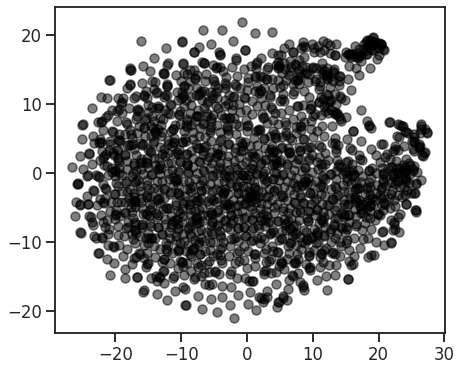

In [15]:
# TODO: Update this cell when you have TDEs in the alerts data. See whether the finkclass of it is "(TNS) TDE" or not, etc.
tns_tde_objIds = ['ZTF24aaahxwr', 'ZTF24aaecooj', 'ZTF20aahmtso', 'ZTF22aafujzv', 'ZTF22aadesap', 'ZTF18aabdajx', 'ZTF21aanxhjv', 'ZTF22abegjtx']

# indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['TNS (TDE)']]) > 0 else 0, 1, test_finkclasses)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][tns_tde_indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][tns_tde_indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][tns_tde_indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][tns_tde_indicator == 1],
    c='#cc4c02', s=150
)

## Using the multi-dim encoded representations for sim search

In [16]:
test_outputs_condensed.shape

(1752, 1, 160, 2)

In [28]:
# Redefine plot_lc. This is ONLY done because we want to look at the query and the closest lc side by side.
# So here we pass an axes as input (which means fig needs to be created beforehand).
# Some motivation from here: https://stackoverflow.com/a/66371682

def plot_lc_ax_visualize(
        df_alerts, name, title_suffix='', fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        sigmapsf_column='sigmapsf', finkclass_column='finkclass', objectId_column='objectId',
        ax=None
):
    """Plots photometry for the given name (objectId) from the alerts dataframe.

    Parameters
    ----------
    name: str
        objectID
    """
    if ax is None:
        ax = plt.gca()

    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    for filt in np.unique(pdf[fid_column]):
        # select data from one filter at a time
        maskFilt = pdf[fid_column] == filt

        ax.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        ax.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls='', marker='^', color=colordic[filt]
        )

        if finkclass_column is not None:
            _offset_x = (pdf[maskFilt][jd_column].max() - pdf[maskFilt][jd_column].min()) / 200
            _offset_y = (pdf[maskFilt][magpsf_column].max() - pdf[maskFilt][magpsf_column].min()) / 100
            for x, y, string in zip(pdf[maskFilt][jd_column], pdf[maskFilt][magpsf_column], pdf[maskFilt][finkclass_column]):
                ax.text(
                    x+_offset_x, y+_offset_y, string,
                    color=colordic[filt]
                )

    ax.invert_yaxis()
    ax.legend()
    ax.set_title(f'{pdf[objectId_column].unique()[0]}'+': '+title_suffix)
    ax.set_xlabel('Modified Julian Date')
    ax.set_ylabel('Magnitude')

In [20]:
## Requires `pip install faiss-cpu` ##

import numpy as np
import pandas as pd 
import faiss

train_outputs_condensed = np.load('evaluate_train_outputs_condensed.npy')  # (num_test_examples, num_sample, num_ref_points, latent_dim)
test_outputs_condensed = np.load('evaluate_test_outputs_condensed.npy')  # (num_test_examples, num_sample, num_ref_points, latent_dim)

outputs = [train_outputs_condensed, test_outputs_condensed]
processed_outputs = []
for o in outputs:
    o = o.squeeze()  # This will remove the num_sample dimension if num_sample=1. If not, squeeze() must be replaced with `mean()`.
    # Below idea of flattening came from https://ai.stackexchange.com/questions/37233/similarities-between-2d-vectors-to-flatten-or-to-not
    o = o.reshape(o.shape[0], -1)  # Flatten across the different filters.
    processed_outputs.append(o)

assert processed_outputs[0].shape[1] == processed_outputs[1].shape[1]
vector_dimension = processed_outputs[0].shape[1]  # this is the no. of reference points. For e.g., 160.
index = faiss.IndexFlatL2(vector_dimension)
faiss.normalize_L2(processed_outputs[0])  # Train data is our database.
index.add(processed_outputs[0])

Another option is to take the mean across the filter dimension, as done for the projection plots above.

In [35]:
processed_outputs[1].shape[0]

1752

/tmp/ipykernel_2613017/2138161994.py:29: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2, figsize=(15, 5))


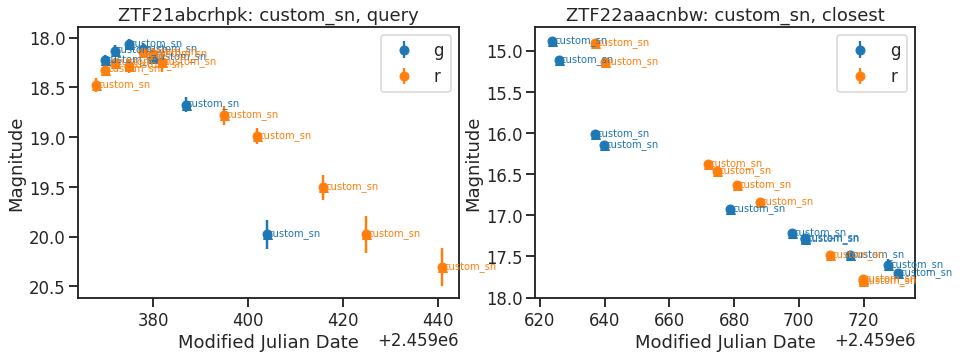

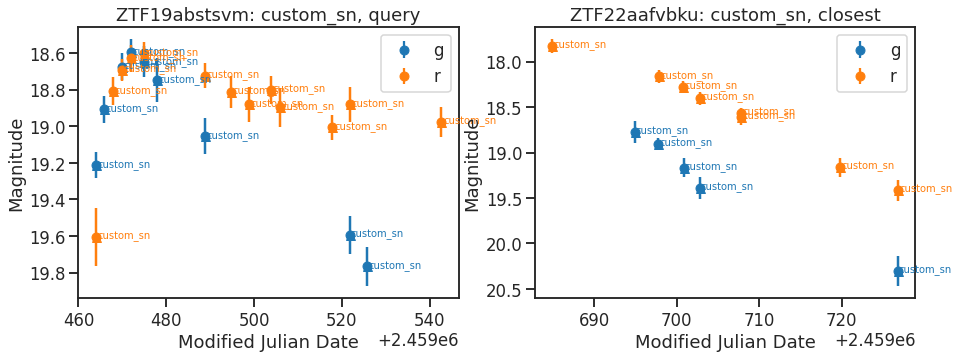

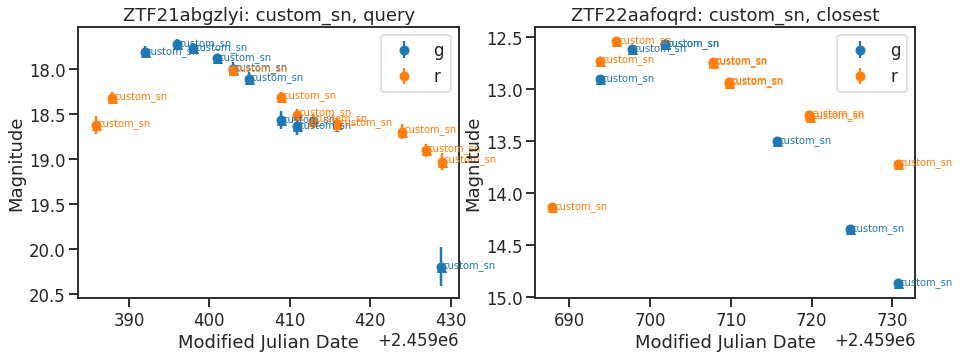

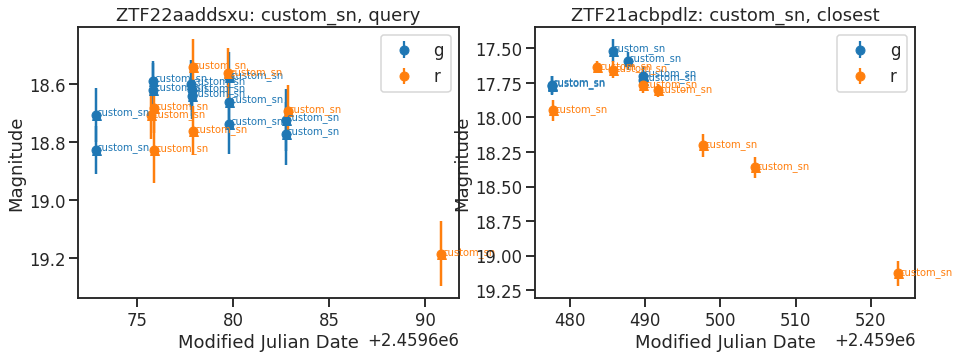

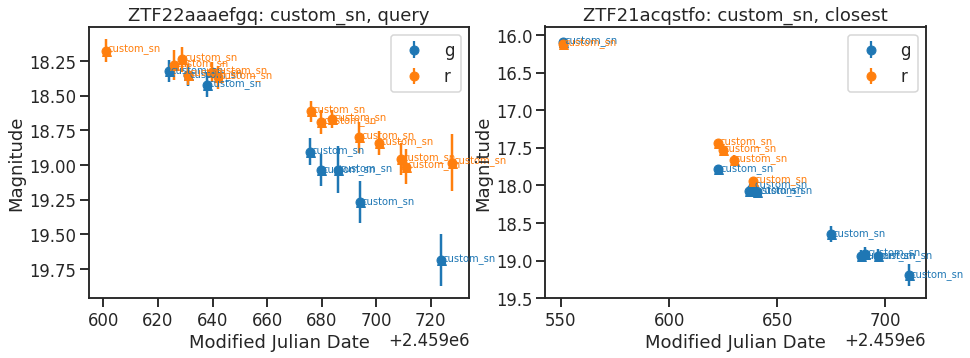

...

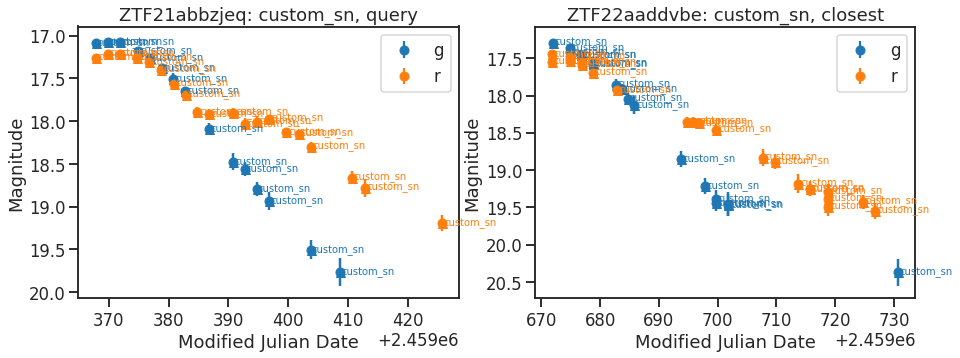

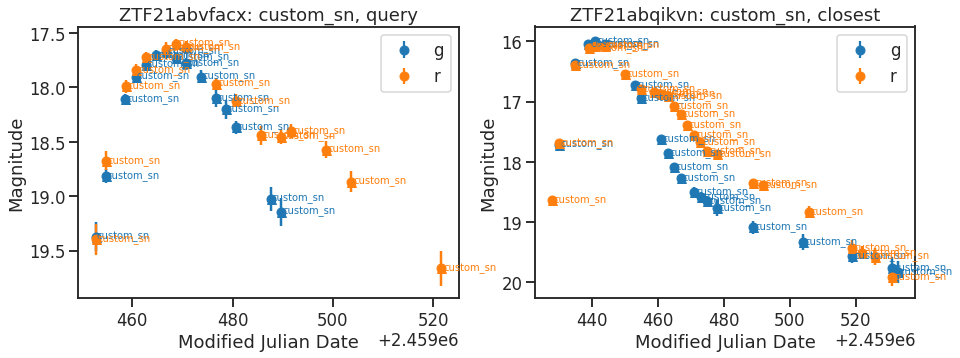

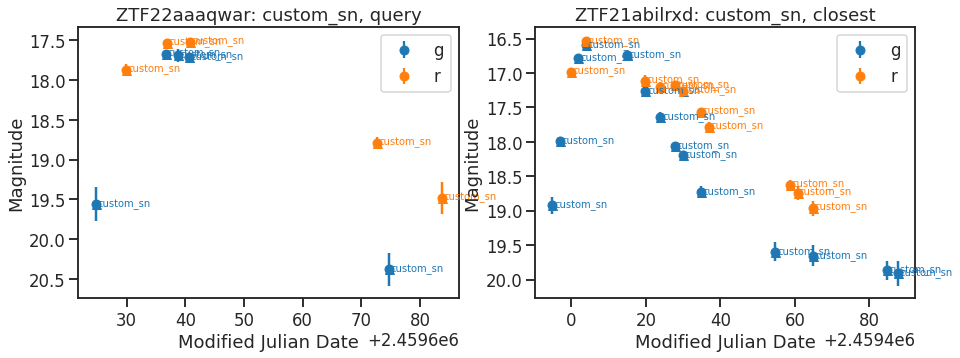

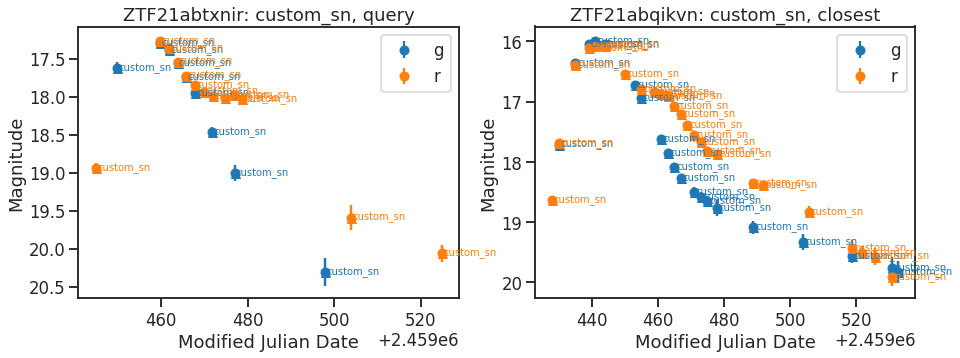

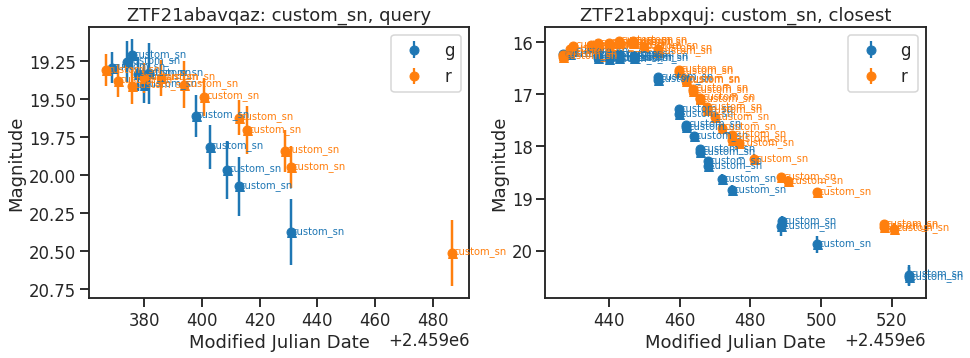

Error in callback <function flush_figures at 0x14f6f5470280> (for post_execute):


KeyboardInterrupt: 

In [51]:
#search_vector = np.linspace(0, 1, 320).astype(np.float32)  # Should be float32: https://github.com/facebookresearch/faiss/issues/461
example_idxs = [104, 506, 182, 81, 1521, 903, 1739, 3]  # Each can lie from [0, processed_outputs[1].shape[0]-1]
# for idx in example_idxs:
for idx in range(processed_outputs[1].shape[0]):
    QUERY_VECTOR = processed_outputs[1][idx]
    search_vector = QUERY_VECTOR.astype(np.float32)
    _vector = np.array([search_vector])
    faiss.normalize_L2(_vector)

    k = index.ntotal
    distances, ann = index.search(_vector, k=k)

    results = pd.DataFrame({'distances': distances[0], 'ann': ann[0]})

    currObjId = test_objIds[idx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']

    tcurrObjId = train_objIds[int(results.iloc[0]['ann'])]
    tcurrObjId_index = np.where(total_objIds == tcurrObjId)
    tcurrCommonFinkclass = total_common_finkclasses[tcurrObjId_index].squeeze()
    tcurrCommonFinkclass = tcurrCommonFinkclass[tcurrCommonFinkclass != '0']

    # NOTE: Currently our data has only custom_sn and custom_agn, so we use these conditions. But need to comment below condition or change when new classes are added.
    if 'custom_sn' not in tcurrCommonFinkclass or 'custom_sn' not in currCommonFinkclass:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    plot_lc_ax_visualize(df_alerts, test_objIds[idx], ax=ax[0], title_suffix=','.join(currCommonFinkclass)+', query')  # this is the query.
    plot_lc_ax_visualize(df_alerts, train_objIds[int(results.iloc[0]['ann'])], ax=ax[1], title_suffix=','.join(tcurrCommonFinkclass)+', closest')  # this is the closest to the query in the database.
    # plot_lc(df_alerts, test_objIds[idx])  # this is the query.
    # plot_lc(df_alerts, train_objIds[int(results.iloc[0]['ann'])]) # this is the closest to the query in the database.

/tmp/ipykernel_2613017/3276513633.py:28: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2, figsize=(15, 5))


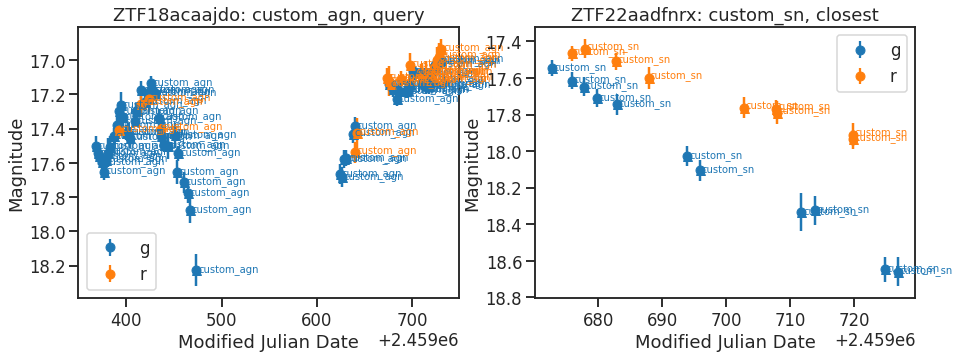

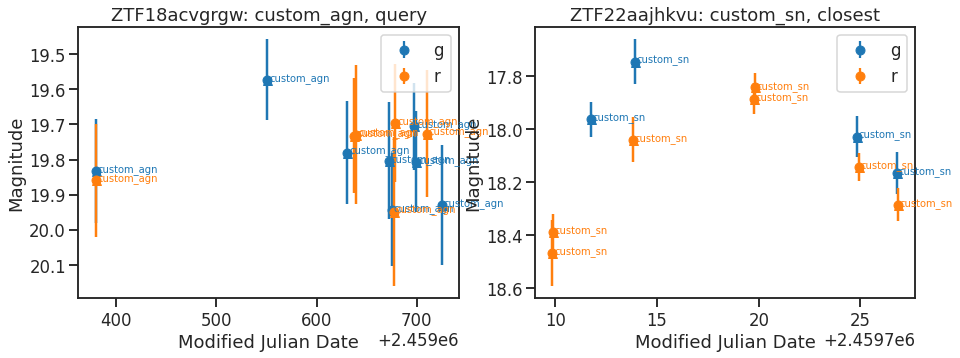

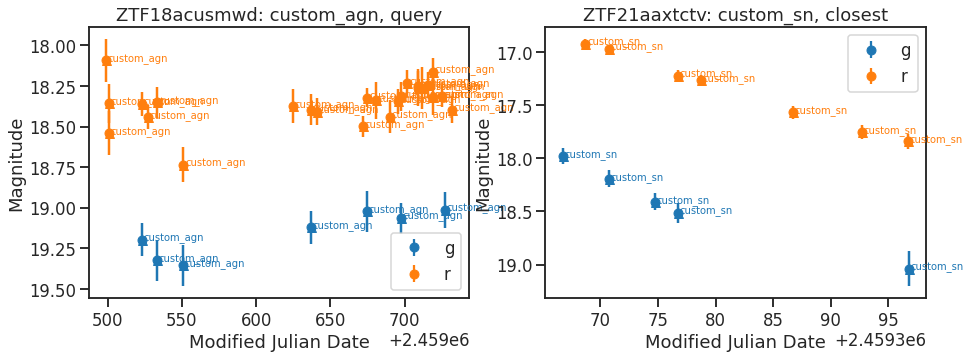

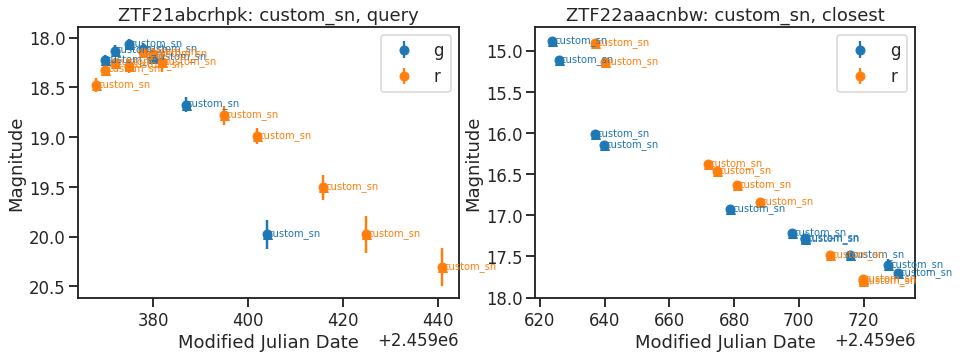

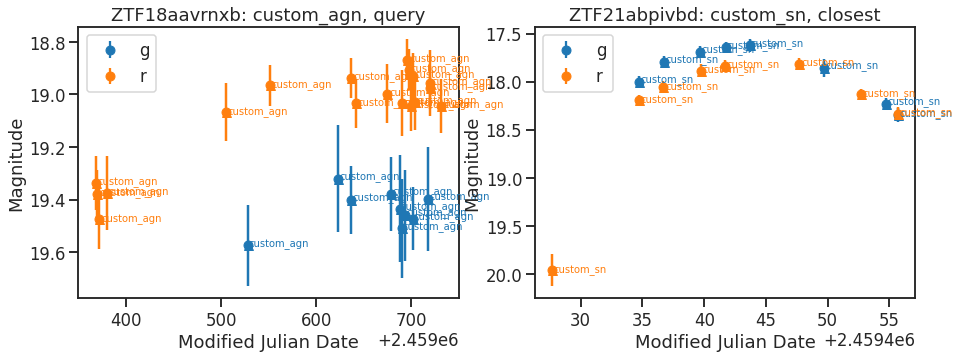

...

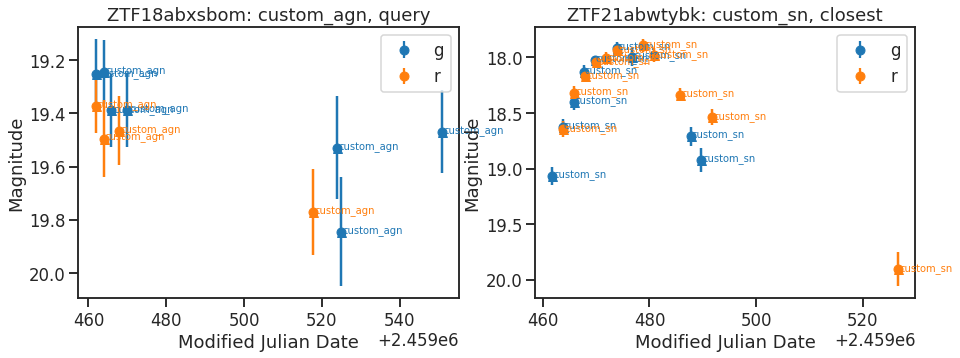

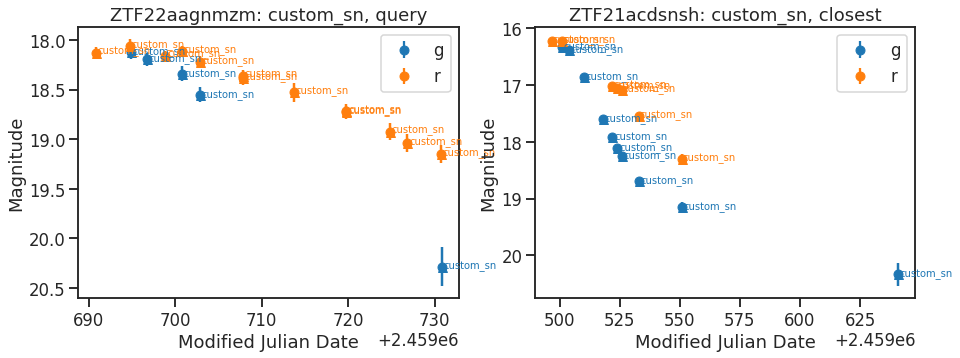

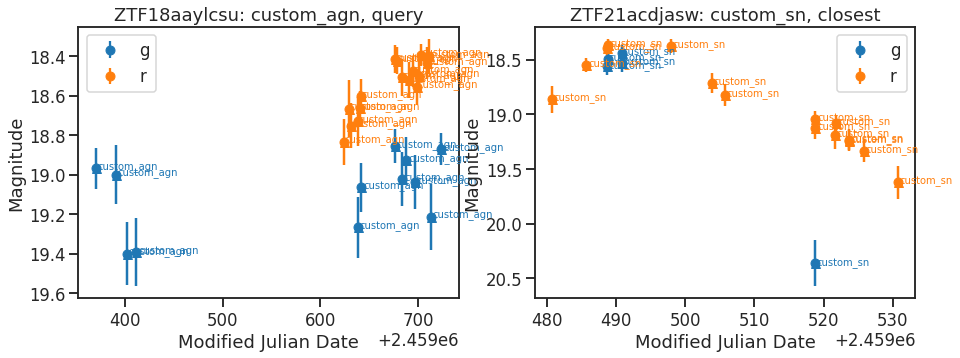

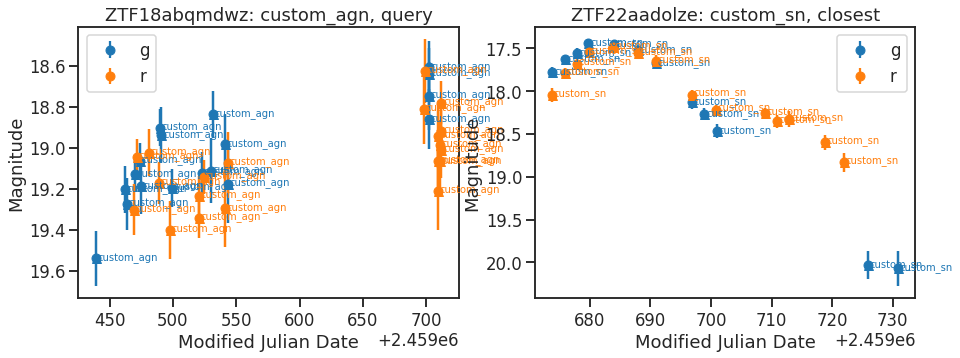

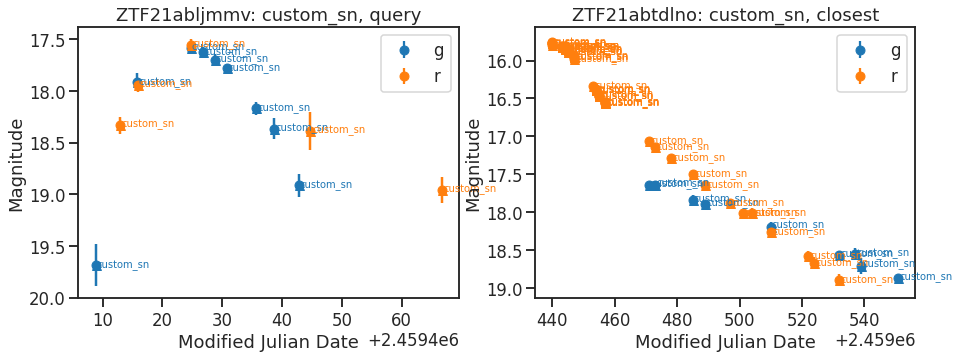

Error in callback <function flush_figures at 0x14f6f5470280> (for post_execute):


KeyboardInterrupt: 

In [52]:
#search_vector = np.linspace(0, 1, 320).astype(np.float32)  # Should be float32: https://github.com/facebookresearch/faiss/issues/461
example_idxs = [104, 506, 182, 81, 1521, 903, 1739, 3]  # Each can lie from [0, processed_outputs[1].shape[0]-1]
# for idx in example_idxs:
for idx in range(processed_outputs[1].shape[0]):
    QUERY_VECTOR = processed_outputs[1][idx]
    search_vector = QUERY_VECTOR.astype(np.float32)
    _vector = np.array([search_vector])
    faiss.normalize_L2(_vector)

    k = index.ntotal
    distances, ann = index.search(_vector, k=k)

    results = pd.DataFrame({'distances': distances[0], 'ann': ann[0]})

    currObjId = test_objIds[idx]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']

    tcurrObjId = train_objIds[int(results.iloc[0]['ann'])]
    tcurrObjId_index = np.where(total_objIds == tcurrObjId)
    tcurrCommonFinkclass = total_common_finkclasses[tcurrObjId_index].squeeze()
    tcurrCommonFinkclass = tcurrCommonFinkclass[tcurrCommonFinkclass != '0']

    # NOTE: Currently our data has only custom_sn and custom_agn, so we use these conditions. But need to comment below condition or change when new classes are added.
    if 'custom_sn' not in tcurrCommonFinkclass:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    plot_lc_ax_visualize(df_alerts, test_objIds[idx], ax=ax[0], title_suffix=','.join(currCommonFinkclass)+', query')  # this is the query.
    plot_lc_ax_visualize(df_alerts, train_objIds[int(results.iloc[0]['ann'])], ax=ax[1], title_suffix=','.join(tcurrCommonFinkclass)+', closest')  # this is the closest to the query in the database.
    # plot_lc(df_alerts, test_objIds[idx])  # this is the query.
    # plot_lc(df_alerts, train_objIds[int(results.iloc[0]['ann'])]) # this is the closest to the query in the database.

## Looking at the light curves

In [23]:
df_alerts.head(2)

,objectId,candid,magpsf,sigmapsf,fid,jd,ra,dec,tnsclass,cdsxmatch,roid,mulens,snn_snia_vs_nonia,snn_sn_vs_all,rf_snia_vs_nonia,rf_kn_vs_nonkn,tracklet,lc_features_g,lc_features_r,finkclass
0,ZTF21aacuhiz,1965201715315015004,20.367006,0.211947,2,2.459720e+06,202.839070,58.536919,Unknown,AGN,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.024749755859375, 'anderson_dar...","{'amplitude': 0.24485301971435547, 'anderson_d...",custom_agn
3,ZTF21aajxlly,1939418406215015004,18.624544,0.152774,1,2.459694e+06,217.804327,-21.425118,Unknown,AGN,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.1172494888305664, 'anderson_da...","{'amplitude': 0.2492504119873047, 'anderson_da...",custom_agn


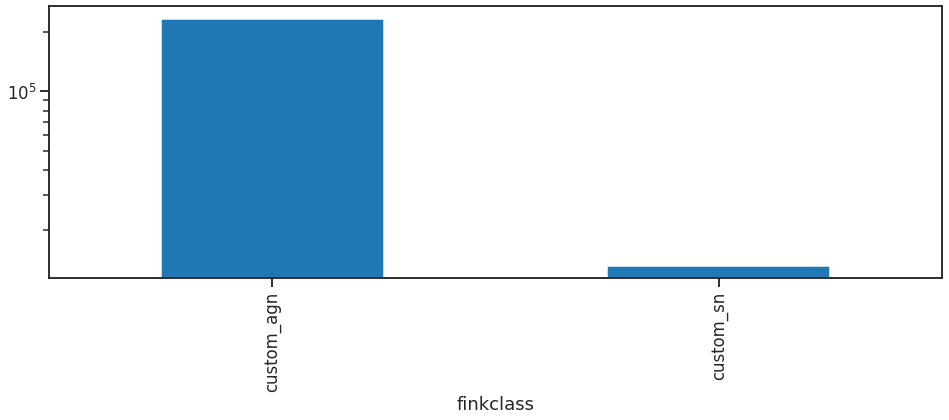

In [64]:
# Note the below histogram (or bar plot) is based on the alerts. The finkclass distribution plots above
# plotted them based on the light curves.
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
df_alerts['finkclass'].value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')

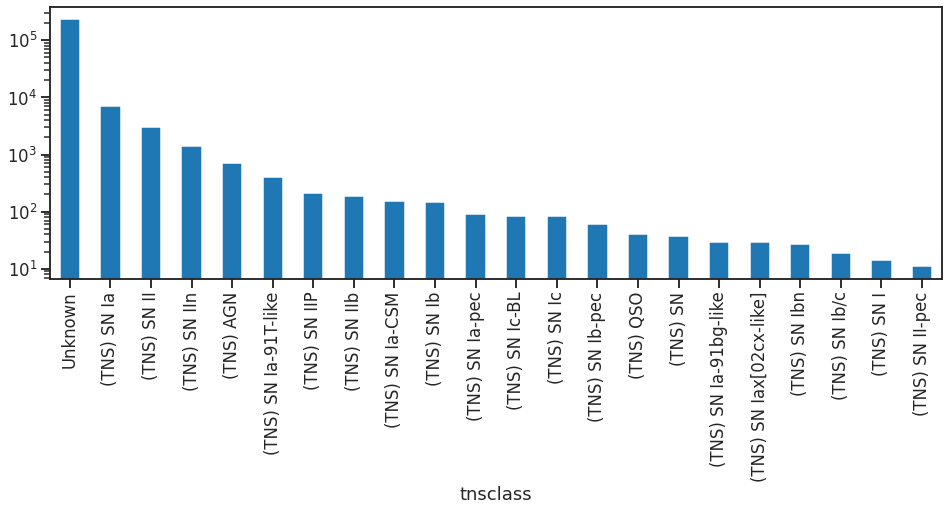

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
df_alerts['tnsclass'].value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')

In [27]:
test_cv_objIds = []
for i, oi in enumerate(total_objIds):
    if oi not in test_objIds:
        continue
    # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
    fclasses = total_common_finkclasses[i, :]
    if 'CataclyV*' in fclasses:  # TODO: Update when you finalize what exactly CV strings need to be included. Add those here if required.
        test_cv_objIds.append(oi)

for test_cv_objId in test_cv_objIds:
    plot_lc(df_alerts, test_cv_objId)

## Old analysis

Selecting points in the latent space manually and plotting their light curves to search for similarity

### Example 1

In [23]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] > 3) & (outputs_condensed_condensed_transformed[:, 1] > 1)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

NameError: name 'outputs_condensed_condensed_transformed' is not defined

In [ ]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

In [ ]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

In [ ]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

In [ ]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

In [ ]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] < -2.5) & (outputs_condensed_condensed_transformed[:, 1] < -1.9)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

In [ ]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

In [ ]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

In [ ]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

In [ ]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

Example 3

In [ ]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] < -2) & (outputs_condensed_condensed_transformed[:, 0] > -3) &
    (outputs_condensed_condensed_transformed[:, 1] > -1.5) & (outputs_condensed_condensed_transformed[:, 1] < -1)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

In [ ]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

In [ ]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

In [ ]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

In [ ]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

## No. of datapoints in light curves across the entire dataset

TODO: Make a detailed analysis of seq_len vs their finkclass (most-common-across-alerts). I previously saw only SN and SN-candidate to have seq_len > 30.

TODO: Is seq_len a good indicator of light curve duration? seq_len is total no. of datapoints including all bands. Perhaps we just need `max_length(pdf[filter1], pdf[filter2])`

In [16]:
def get_lc(
        df_alerts, name, fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        objectId_column='objectId', sigmapsf_column='sigmapsf', finkclass_column='finkclass',
        #extract_subset=False, start_index=None, end_index=None
        make_first_time_zero=True, convert_to_tensor=False, normalize_times=False,
        local_time_normalization=False, max_time=None, min_time=None
    ):
    """Get the light curve given an alerts dataframe (df_alerts) and the objectId (name).

    Returns a tuple (object_Id, tt, vals, mask, labels)
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}, so cannot make a light curve!')

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    observation_data, observation_mask = [], []
    # for filt in np.unique(pdf['fid']):
    # Don't loop over pdf['fid'] since in pdf, we might not get all filters. For creating the dataset, we need fixed-sized arrays, so we should select all filters instead of filters seen in this pdf.
    for filt in np.unique(df_alerts[fid_column]):
        #if extract_subset:
        #    maskFilt = pdf[fid_column] == filt
        #    observation_data.append(
        #        (pdf[magpsf_column] * maskFilt).iloc[start_index:end_index]
        #    )
        #    observation_mask.append(
        #        maskFilt.astype(int)
        #    )
        #else:
        maskFilt = pdf[fid_column] == filt
        observation_data.append(
            pdf[magpsf_column] * maskFilt  # because when observation for this filter is not present, we want to replace the observed value with zero, as done in the mTAN code.
        )
        observation_mask.append(
            maskFilt.astype(int)
        )

    observation_data = np.array(observation_data).T  # after transpose: seqlen x num_channels
    observation_mask = np.array(observation_mask).T  # after transpose: seqlen x num_channels

    times = np.expand_dims(pdf[jd_column], 1)  # Add dimension at the 1st index to prepare for concatenation.
    #data = np.concatenate((observation_data, observation_mask, times), axis=1)

    if make_first_time_zero:
        # As per the Physionet dataset (at least) from the mTAN paper, the times always start at zero. Their time units are also in hours. So this replicates that.
        # Make the first time to zero. The below two lines are only for machine learning purposes since the time must always start at zero for all light curves.
        times = times - times[0]
        #times = times * 24  # to convert times into hours.

    if normalize_times:
        # NOTE: If you use get_lc for different length light curves, note the possible caveat that a normalized time value of 1 means the same for two very different length light curves. It's possible that despite this, the relative difference in the times already encodes the information about different duration/length light curves. Not sure definitively.
        times = normalize_time_values(times, local_time_normalization=local_time_normalization, max_time=max_time, min_time=min_time)

    if finkclass_column is not None:  # finkclass_column will be None when getting the light curve from the API service instead of polling the alerts.
        common_finkclasses = df_alerts[df_alerts[objectId_column] == name][finkclass_column].mode().tolist()
    else:
        common_finkclasses = [None]

    if convert_to_tensor:
        times = torch.from_numpy(times)
        observation_data = torch.from_numpy(observation_data)
        observation_mask = torch.from_numpy(observation_mask)

    data = (name, times, observation_data, observation_mask, common_finkclasses)

    return data

def normalize_time_values(times, local_time_normalization=False, max_time=None, min_time=None):
    """`times` must start with zero and be in units of hours. This function assumes that.
    times are multipled by 48 after normalization which means the normalized time valus lie in [0, 48] hours.
    """
    if local_time_normalization:
        normalized_times = (times - np.min(times)) / (np.max(times) - np.min(times))
    else:  # Means global normalization must be used. In this case, max_time argument will be used.
        if max_time is None or min_time is None:
            raise ValueError("max_time and min_time both must be provided if using global time normalization.")
        assert max_time > np.min(times)  # Otherwise time will become negative.
        normalized_times = (times - min_time) / (max_time - min_time)
    normalized_times *= 48  # Doing this is not needed since anyways variable_time_collate_fn will normalize to the [0, 1] range.
    return normalized_times

28.071705868919846 21.0


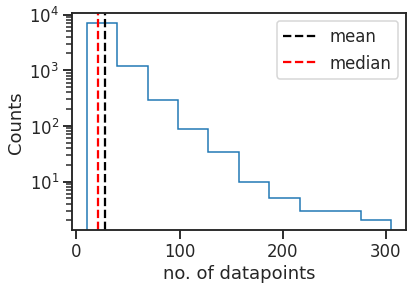

In [29]:
import numpy as np
import pandas as pd

# NOTE: num_datapoints_lcs is the no. of points summed over all filters.
num_datapoints_lcs = np.load('num_datapoints_lcs.npy')

import matplotlib.pyplot as plt
plt.hist(num_datapoints_lcs, histtype='step')  # Duration of lcs are multiplied by 24 to convert into hrs.
plt.yscale('log')
plt.xlabel('no. of datapoints')
plt.ylabel('Counts')
plt.axvline(x=np.mean(num_datapoints_lcs), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(num_datapoints_lcs), linestyle='--', c='red', label='median')
plt.legend()

print(np.mean(num_datapoints_lcs), np.median(num_datapoints_lcs))

6146.296063014879 7130.4884723983705


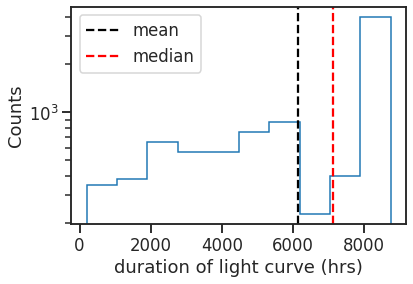

In [30]:
import numpy as np
import pandas as pd

duration_lcs = np.load('duration_lcs.npy')

import matplotlib.pyplot as plt
plt.hist(duration_lcs, histtype='step')  # Duration of lcs are multiplied by 24 to convert into hrs.
plt.yscale('log')
plt.xlabel('duration of light curve (hrs)')
plt.ylabel('Counts')
plt.axvline(x=np.mean(duration_lcs), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(duration_lcs), linestyle='--', c='red', label='median')
plt.legend()

print(np.mean(duration_lcs), np.median(duration_lcs))

This plot also tells us how many lcs are completely contained in the data range and how many are only partially captured. Because if `duration_lc` approximately equals the data range, then that lc either started near the start of the data range and ended near the end of data range OR is even longer than that -- for the latter, as long as the data range is large enough (>= 1 yr), many points of the lc will be covered. Whereas very small duration_lc means that the transient is very short-lived if entirely contained in the data range or only a small part of the lc is captured in the data range: the latter are probably contaminants.

For the SN+AGN data, it's expected that many lcs will be fully contained in the data range and will extend longer than that. This is because SN can live up to a few years and AGNs even longer than that. Indeed, the histogram shows the peak is towards ~8000 hrs, close to 1 yr.

## `max_mag - min_mag` across light curves

This is calculated across all bands for a given light curve.

0.8052192297284531 0.6530637741088867 0.4587740898132324 0.5298844156358856


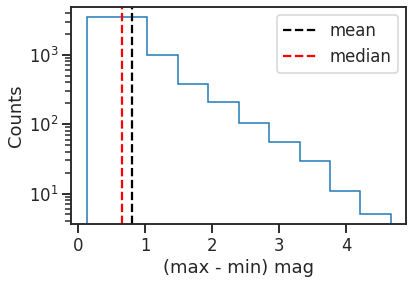

In [31]:
import numpy as np
import pandas as pd
from scipy.stats import iqr

min_max_magdiffs = np.load('min_max_magdiffs.npy')

import matplotlib.pyplot as plt
plt.hist(min_max_magdiffs, histtype='step')
plt.yscale('log')
plt.xlabel('(max - min) mag')
plt.ylabel('Counts')
plt.axvline(x=np.mean(min_max_magdiffs), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(min_max_magdiffs), linestyle='--', c='red', label='median')
plt.legend()

print(np.mean(min_max_magdiffs), np.median(min_max_magdiffs), iqr(min_max_magdiffs), np.std(min_max_magdiffs))

In [32]:
min_max_magdiffs = np.load('min_max_magdiffs.npy')
inds = np.where(min_max_magdiffs > 4)
total_objIds[inds], total_common_finkclasses[inds]

(array(['ZTF21abpxquj', 'ZTF20aamawcx', 'ZTF18abijskz', 'ZTF17aacngcr',
        'ZTF21abuibjs', 'ZTF21acpfndw', 'ZTF21acdsnsh', 'ZTF18aaegrnn',
        'ZTF18aaisdqw'], dtype='<U12'),
 array([['custom_sn'],
        ['custom_agn'],
        ['custom_agn'],
        ['custom_agn'],
        ['custom_sn'],
        ['custom_sn'],
        ['custom_sn'],
        ['custom_agn'],
        ['custom_agn']], dtype='<U10'))

## Projection (PCA/UMAP/t-SNE) colored with

### min mags of lcs

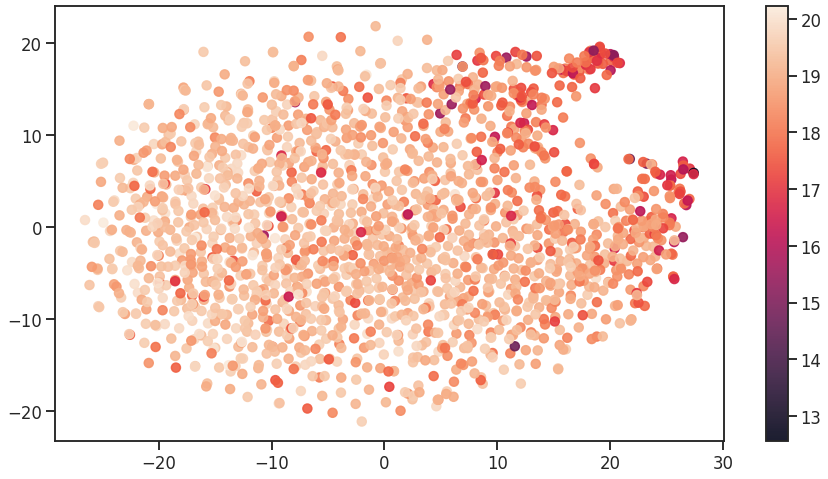

In [33]:
min_mags = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    min_mags.append(obs[obs != 0.0].min())

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=min_mags, alpha=0.9
)
ax.set_xlabel('Projection dimension 1')
ax.set_ylabel('Projection dimension 2')
plt.colorbar(sc)

(Only for the SN+AGN data)
- The plot above shows that SN tend to be brighter than AGNs. Because if one compares the above with the same plot above (where the SN and AGN points are marked in different colours), one seens darker points in the above correspond mainly to SN.
- Why might this may happen? Is it because supernovae are closer to us than AGNs in this dataset? The challenge is that we have no redshifts.

### length of light curve

Text(0, 0.5, '$\\log_{10}(\\mathrm{lc\\_length})$')

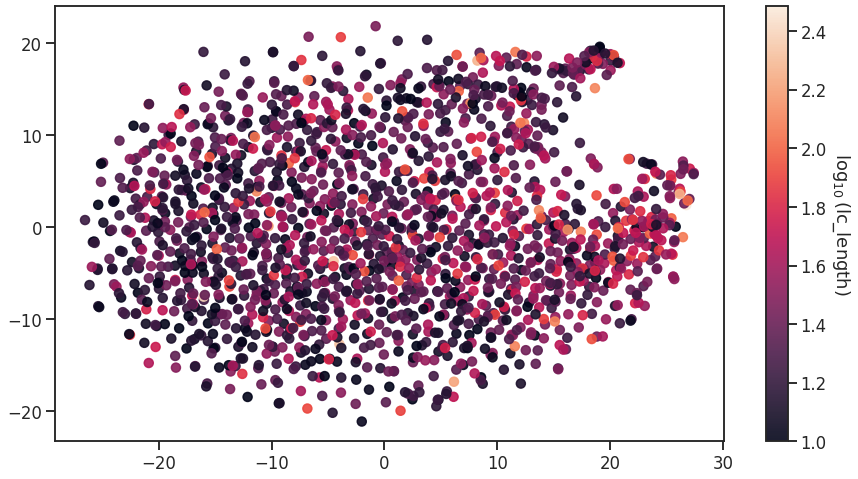

In [34]:
length_lc = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    length_lc.append(len(data[1]))

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=np.log10(length_lc), alpha=0.9
)
cbar = plt.colorbar(sc)
ax.set_xlabel('Projection dimension 1')
ax.set_ylabel('Projection dimension 2')
cbar.ax.set_ylabel('$\log_{10}(\mathrm{lc\_length})$', rotation=270, labelpad=25)

Expectation in the above: Perhaps the model shouldn't cluster based on the length of the lc since the ELBO term in the loss function normalizes based on the length.

### time of min mag (i.e., peak) since lc start

Text(0, 0.5, 'time_min_mag (days)')

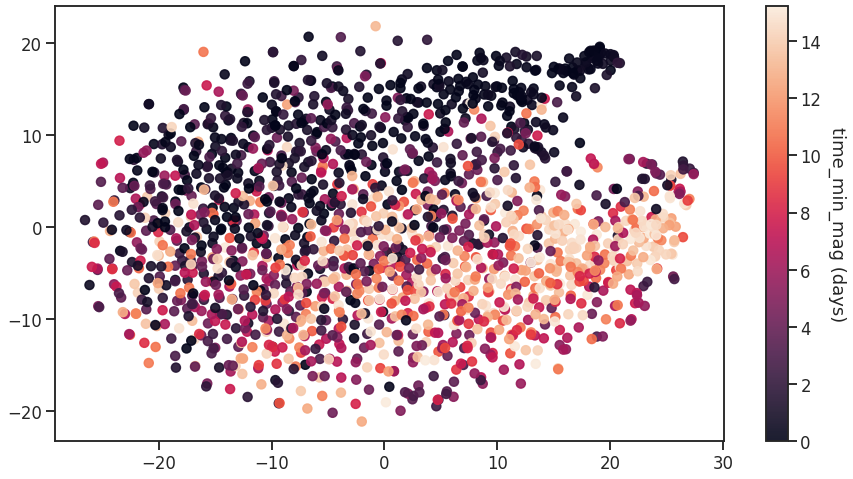

In [37]:
time_min_mag = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    t = data[1]
    obs = np.where(obs != 0, obs, np.inf)
    tmm = t[np.where(obs == obs.min())[0]]
    time_min_mag.append(tmm/24 if time_in_hrs else tmm)

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=time_min_mag, alpha=0.9
)
cbar = plt.colorbar(sc)
ax.set_xlabel('Projection dimension 1')
ax.set_ylabel('Projection dimension 2')
cbar.ax.set_ylabel('time_min_mag (days)', rotation=270, labelpad=25)

Ideally the model should not cluster the light curves based on the time since the peak since there are four cases: short-lived and partially/fully contained in the data range, long-lived and partially/fully contained in data range, and based on the data range, time of mag peak will differ. So time of mag peak is non-physical since we don't work with full lcs, and so the model must not heavily rely on this.

However, the time of the peak indicates something about the shape of the light curve (assuming the same class of transient and assuming we know the general evolution of the light curve of that class), so for a given class (SN or AGN), it's okay and plausible if the model uses this information. Again if classes of transients are different but their time of peak mag are the same/similar, the model should NOT cluster them closely.

Considering all these factors, the above plot makes sense and is not weird.

### mean mag

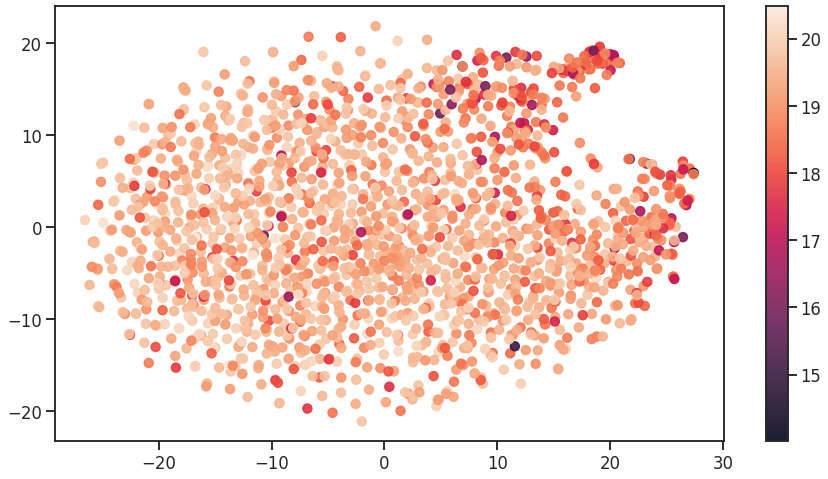

In [35]:
mean_mags = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    mean_mags.append(obs[obs != 0.0].mean())

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=mean_mags, alpha=0.9
)
ax.set_xlabel('Projection dimension 1')
ax.set_ylabel('Projection dimension 2')
plt.colorbar(sc)

### finkclass

In [ ]:
finkclasses = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    cl = data[-1][0]
    finkclasses.append(cl)

from sklearn import preprocessing
le = preprocessing.LabelEncoder()
finkclasses_encoded = le.fit_transform(finkclasses)  # use le.inverse_transform to get the string from the encoded value.

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=finkclasses_encoded, alpha=0.9
)
ax.set_xlabel('Projection dimension 1')
ax.set_ylabel('Projection dimension 2')
plt.colorbar(sc)

## Length of light curve vs finkclass

In [36]:
finkclasses = []
length_lc =[]
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    cl = data[-1][0]
    len_lc = len(data[1])
    finkclasses.append(cl)
    length_lc.append(len_lc)

finkclasses = np.expand_dims(np.array(finkclasses), 1)
length_lc = np.expand_dims(np.array(length_lc), 1)
df = pd.DataFrame(np.hstack((finkclasses, length_lc)))
df.columns = ['finkclass', 'len_lc']
# ax.scatter(finkclasses, length_lc)
# plt.show()

Text(0, 0.5, 'len_lc')

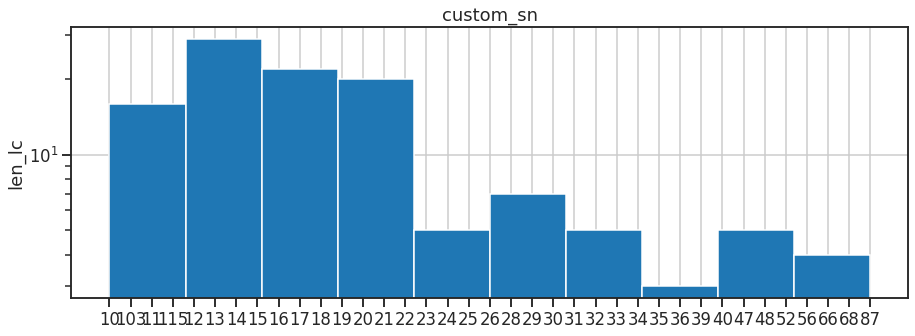

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
df[df['finkclass'] == 'custom_sn']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('custom_sn')
ax.set_xlabel('len_lc')
ax.set_ylabel('Counts')

Text(0, 0.5, 'len_lc')

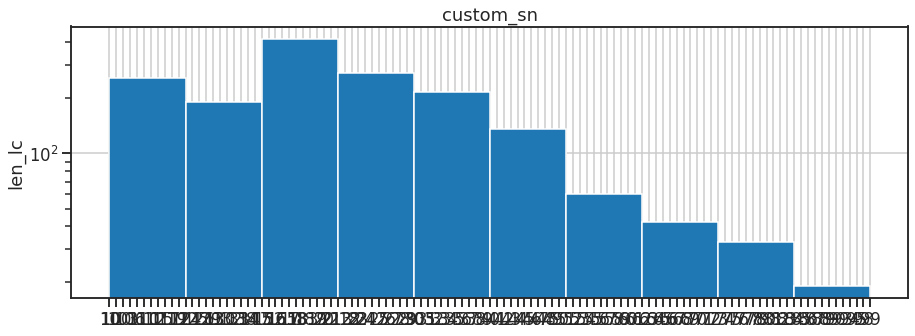

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
df[df['finkclass'] == 'custom_agn']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('custom_sn')
ax.set_xlabel('len_lc')
ax.set_ylabel('Counts')

/tmp/ipykernel_30871/3215621851.py:3: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


Text(0, 0.5, 'len_lc')

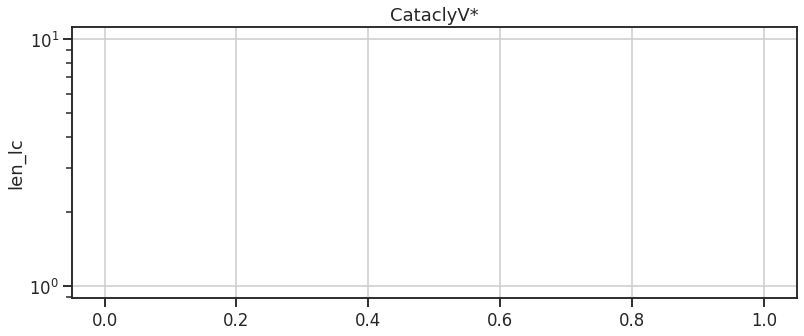

In [39]:
# TODO: Update when you finalize what CV strings are included and update finkclass condition based on that.
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
df[df['finkclass'] == 'CataclyV*']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('CataclyV*')
ax.set_xlabel('len_lc')
ax.set_ylabel('Counts')

/tmp/ipykernel_30871/2260891752.py:3: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


Text(0, 0.5, 'len_lc')

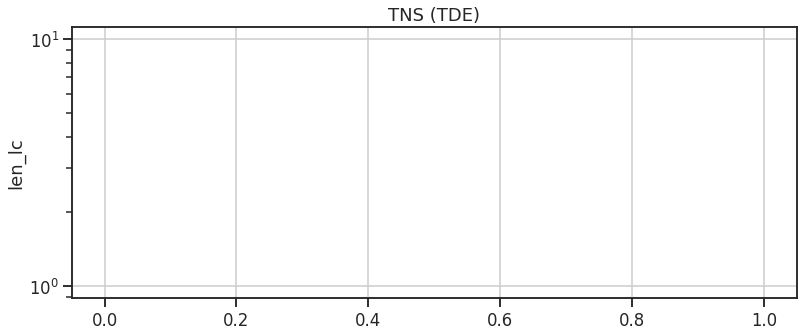

In [40]:
# TODO: Update when you finalize what TDE strings are included and update finkclass condition based on that.
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
df[df['finkclass'] == 'TNS (TDE)']['len_lc'].sort_values().hist(ax=ax)
ax.set_yscale('log')
ax.set_title('TNS (TDE)')
ax.set_xlabel('len_lc')
ax.set_ylabel('Counts')

## Show random light curves

Main point of analysis is to see qualitatively how many light curves are uninteresting (flat with mostly noise).

In [45]:
print(list(df_alerts['finkclass'].unique()))

['custom_agn', 'custom_sn']


In [46]:
np.random.seed(42)
random_objIds = np.random.choice(
    # df_alerts['objectId'].unique(), size=15, replace=False
    df_alerts[df_alerts['finkclass'] == 'custom_stars']['objectId'].unique(), size=4, replace=False
)

for oi in random_objIds:
    plot_lc(df_alerts, oi)

ValueError: 'a' cannot be empty unless no samples are taken

## Show the values of times

In [47]:
# for i, objId in enumerate(df_alerts['objectId'].unique()):
#     data = get_lc(df_alerts, objId, make_first_time_zero=True, convert_to_tensor=False, normalize_times=False)
#     # data = (name, times, observation_data, observation_mask, common_finkclasses)
#     # print(normalize_times(data[1]))
#     print(data[1])
#     if i == 10:
#         break

## Visualize decoded light curves

We don't want to do interpolation, so instead of aiming for a perfect interpolation that matches with the observed points closely, the decoded light curves must only be able to capture relevent features of the light curves (e.g., position and value of the peak of the lc, fade/rise times, etc).

Quantitative analysis of the residuals of the prediction:
- https://support.minitab.com/en-us/minitab/help-and-how-to/statistical-modeling/regression/how-to/nonlinear-regression/interpret-the-results/all-statistics-and-graphs/residual-plots/
- https://stats.stackexchange.com/questions/105670/residual-plot-for-nonlinear-regression

The normal probability plot demarcates deviations from normality. The general pattern in these plots (see the inset plot in the plots in the below cells) seems to indicate that the residuals are right-skewed. See https://en.wikipedia.org/wiki/Normal_probability_plot, which means there are majorly small residuals but few cases where the residuals are high. Based on the visualisations, I expect many of these high residuals to be near the peaks (which are generally not captured well).

Common investigation measures on the residuals:
- ensure there is no peculiar pattern in the residuals (trends, sudden shifts in the values, cyclic pattern).
- normal probability plot

In [12]:
decoded_lcs = np.load('evaluate_test_decoded_lcs.npz')

In [13]:
decoded_lcs.f.arr_2.shape

(4, 305, 2)

In [14]:
decoded_lcs.f.arr_4.shape

(4, 305, 2)

In [15]:
# TODO: Edit prepare_data to also store this value in .npy so that it can be read here.
max_time, min_time = 8763.17888879031, 0.0
min_max_mags = np.load('min_max_mags.npy')

In [21]:
from scipy import stats
from utils import unnormalize_time, unnormalize_mag

# TODO: Ensure again if unnormalize_lcs works as expected.
def plot_decoded_lc(
    decoded_lcs, key, num_filters=2, objId=None,
    unnormalize_lcs=True, min_time=None, max_time=None, min_max_mags=None
):
    """This function assumes batch size=1 is used while storing the decoded_lcs.
    min_max_mags is a 2D numpy array. Each row contains [object ID, min_mag, max_mag].
    """
    pred_x, observed_data, observed_mask, observed_times = decoded_lcs[key]

    print(pred_x.shape, observed_data.shape, observed_mask.shape, observed_times.shape)
    
    assert np.all(observed_times[:, 0] == observed_times[:, 1])  # Because we simply repeated the dimension in the evaluation_unsupervised.py code.
    observed_times = observed_times[:, 0]
    # Set to NaN to ensure non-essential time values for this lc are not shown.
    observed_times[observed_times == 0.0] = np.nan
    # Recall that we use make_first_time_zero=True in prepare_data (see get_lc), so the first time value will be zero
    # But we don't want that first time value to be set to NaN. So we undo that below.
    observed_times[0] = 0.0

    if unnormalize_lcs:
        if min_max_mags is None:
            raise ValueError("min_max_mags must be provided if unnormalize_lcs is True!")
        if objId is None:
            raise ValueError("objId must be provided if unnormalize_lcs is True!")
        row = min_max_mags[np.where(min_max_mags[:,0] == objId)].squeeze()
        if min_time is None or max_time is None:
            raise ValueError("min_time and max_time must be provided if unnormalize_lcs is True!")
        observed_times = unnormalize_time(observed_times, min_time, max_time)
        observed_data = unnormalize_mag(observed_data, observed_mask, float(row[1]), float(row[2]))
        pred_x = unnormalize_mag(pred_x, np.ones_like(observed_mask), float(row[1]), float(row[2]))

    c1 = ['#2b8cbe', '#a6bddb']  # dark and then light blue
    c2 = ['#f03b20', '#feb24c']  # dark and then light orange

    colors = [c1, c2]

    fig, ax = plt.subplots(2, 2, figsize=(15, 15))
#     fig.subplots_adjust(hspace=0)
    for i in range(num_filters):
        # Set unobserved values to NaN so that they don't show up in the plot.
        obs_to_show = observed_data[:, i]
        obs_to_show[observed_mask[:, i] == 0.0] = np.nan

        resid = obs_to_show - pred_x[:, i]

        ax[0, i].plot(observed_times/24 if time_in_hrs else observed_times, obs_to_show, ls = '', marker='o', c=colors[i][1], label=f'observed_{i}')
        ax[0, i].plot(observed_times/24 if time_in_hrs else observed_times, pred_x[:, i], c=colors[i][0], label=f'pred_{i}')
        ax[1, i].scatter(observed_times/24 if time_in_hrs else observed_times, resid, c='black', label=f'observed_{i}-pred_{i}', alpha=0.8)

        ins = ax[1, i].inset_axes([0.05,0.05,0.15,0.15])
#         ins.hist(resid)
        stats.probplot(resid, plot=ins)
        ins.set_xticks([])
        ins.set_yticks([])
        ins.set_ylabel('')
        ins.set_xlabel('')
        ins.set_title('Probability plot', fontsize=10)
        ins.spines[['right', 'top', 'left']].set_visible(False)

        ax[1, i].axhline(y=5*stats.median_abs_deviation(resid[~np.isnan(resid)]), linestyle='--', c='black', alpha=0.8)
        ax[1, i].axhline(y=-5*stats.median_abs_deviation(resid[~np.isnan(resid)]), linestyle='--', c='black', alpha=0.8)
        ax[1, i].axhline(y=0, c='black', alpha=0.8)

        # Set x-axis limits based on its lc only so that we get more detailed understanding of one lc.
        last_non_nan_obs_idx = (~np.isnan(obs_to_show)).cumsum().argmax()
#         ax[0, i].set_xlim([-1, last_non_nan_obs_idx+1])
#         ax[1, i].set_xlim([-1, last_non_nan_obs_idx+1])

        if unnormalize_lcs:
            ax[0, i].set_ylabel('mag')
            ax[0, i].set_xlabel(f'time (days)')
            ax[1, i].set_ylabel('mag - pred_mag')
            ax[1, i].set_xlabel(f'time (days)')
        else:
            ax[0, i].set_ylabel('normalized_mag')
            ax[0, i].set_xlabel(f'normalized time (days)')
            ax[1, i].set_ylabel('normalized_mag - pred_mag')
            ax[1, i].set_xlabel(f'normalized time (days)')

        if i == 0:
            ax[0, i].set_title(key+r'; $g$ filter')
        elif i == 1:
            ax[0, i].set_title(key+r'; $r$ filter')

        ax[0, i].invert_yaxis()
        ax[1, i].invert_yaxis()

    for a in ax:
        for b in a:
            b.legend()

    plt.tight_layout()

    plt.show()

# max_points_lc = -np.Inf
max_points_lc_counters = []
for counter, key in enumerate(decoded_lcs.keys()):
    if decoded_lcs[key][-1].sum() > 150:  # TODO: 200 is used based on the histogram of the #datapoints. Can change if needed.
        # max_points_lc = decoded_lcs[key][-1].sum()
        # max_points_lc_counter = counter
        max_points_lc_counters.append(counter)
    # currObjId = test_objIds[counter]
    # currObjId_index = np.where(total_objIds == currObjId)
    # currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    # currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    # plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    # plot_decoded_lc(decoded_lcs, key)
    # if counter == 10:
    #     break

First showing the lc with the max no. of observed points. Then, some random examples.

$\pm 5\sigma_{\mathrm{mad}}$ region is denoted by the dashed lines. Any value beyond this region can be considered an outlier (see [this paper](https://academic.oup.com/mnras/article/493/3/3825/5762785))

In [22]:
for counter, key in enumerate(decoded_lcs.keys()):
    if counter in max_points_lc_counters:
        currObjId = test_objIds[counter]
        currObjId_index = np.where(total_objIds == currObjId)
        currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
        currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
        if 'custom_sn' not in currCommonFinkclass:
            continue
        plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
        plot_decoded_lc(
            decoded_lcs, key, objId=currObjId,
            unnormalize_lcs=True, min_time=min_time, max_time=max_time,
            min_max_mags=min_max_mags
        )

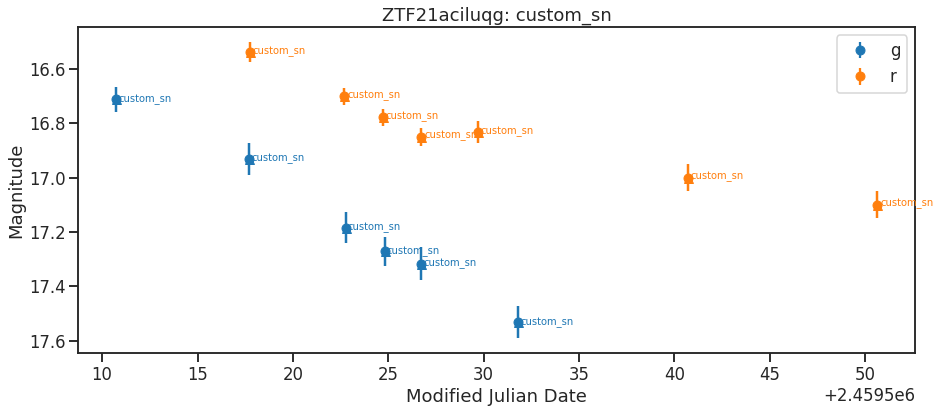

(305, 2) (305, 2) (305, 2) (305, 2)


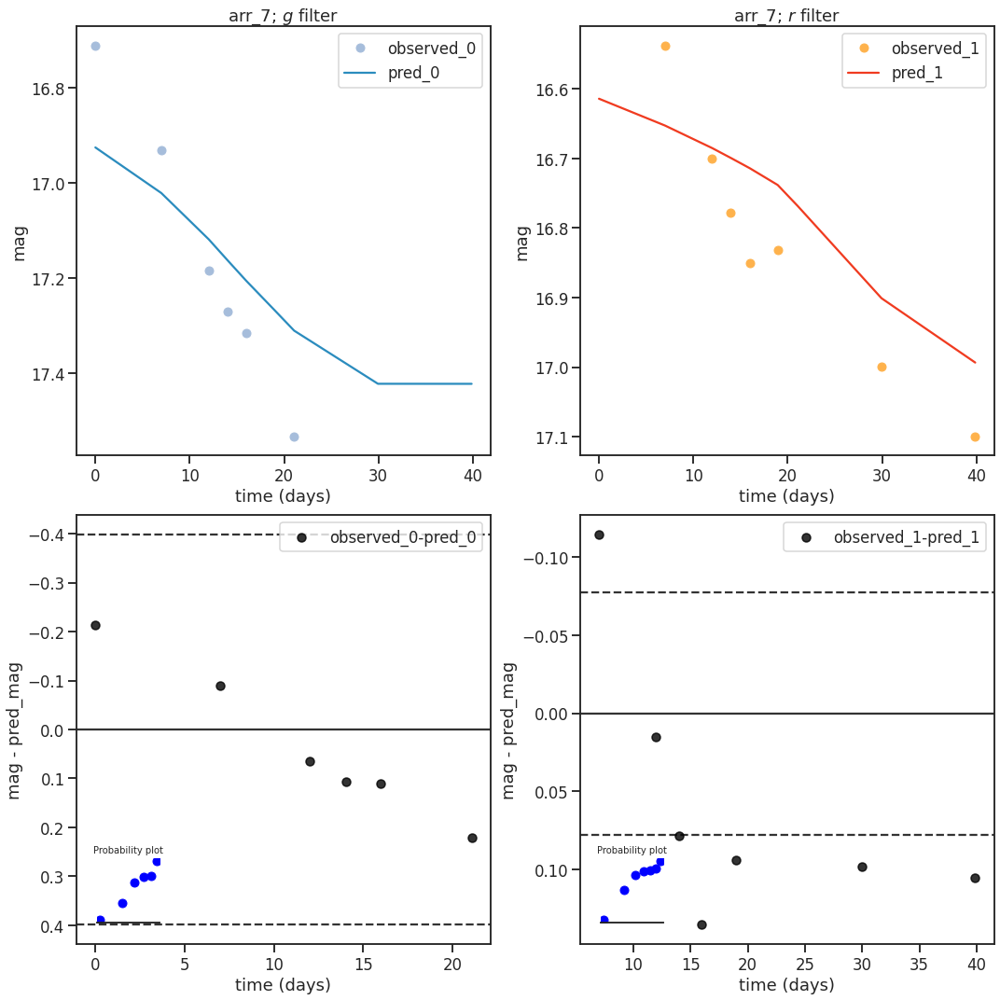

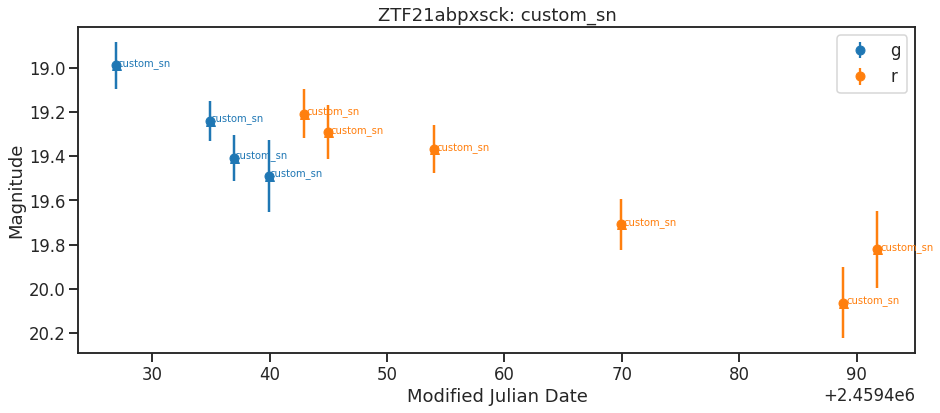

(305, 2) (305, 2) (305, 2) (305, 2)


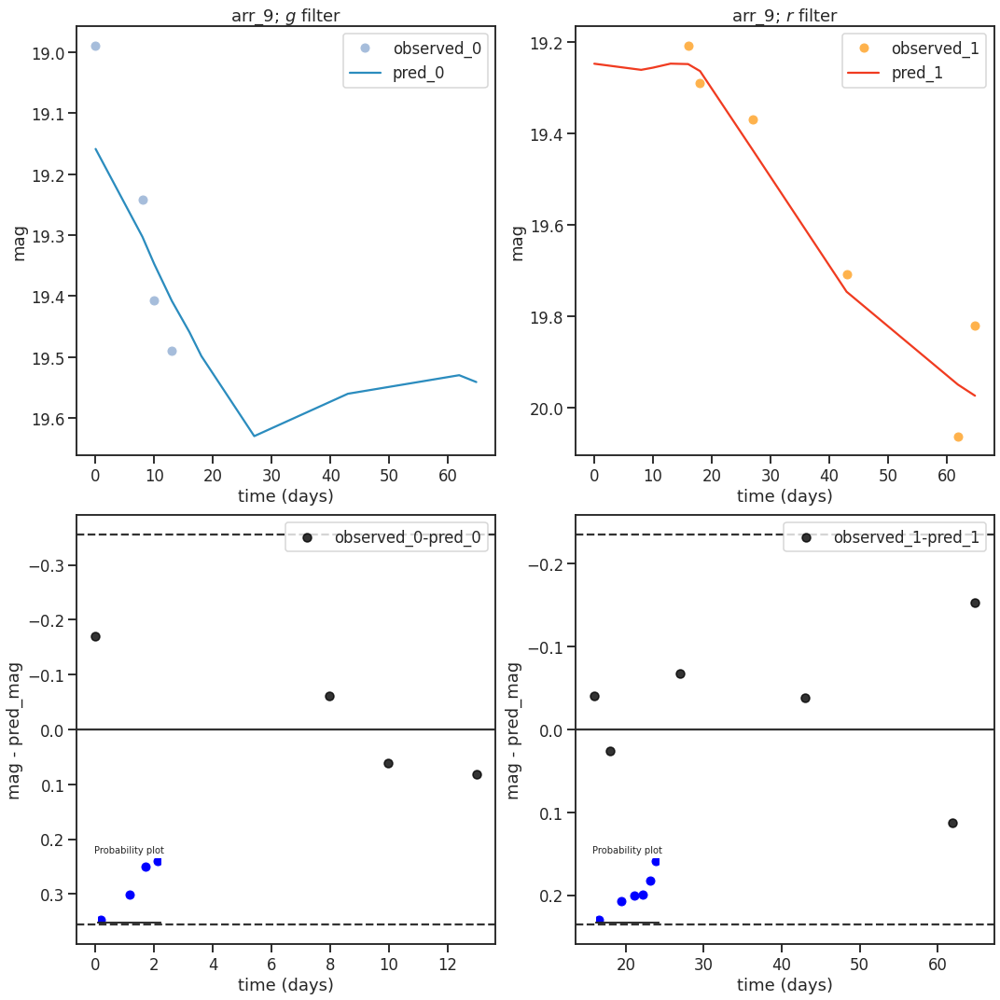

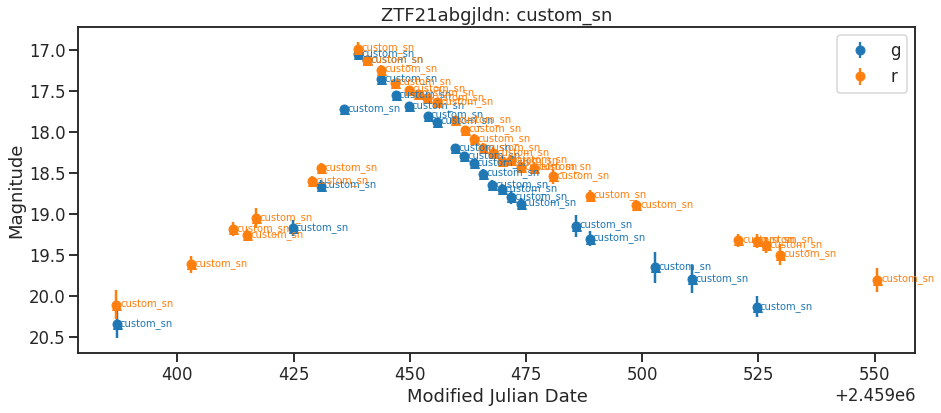

(305, 2) (305, 2) (305, 2) (305, 2)


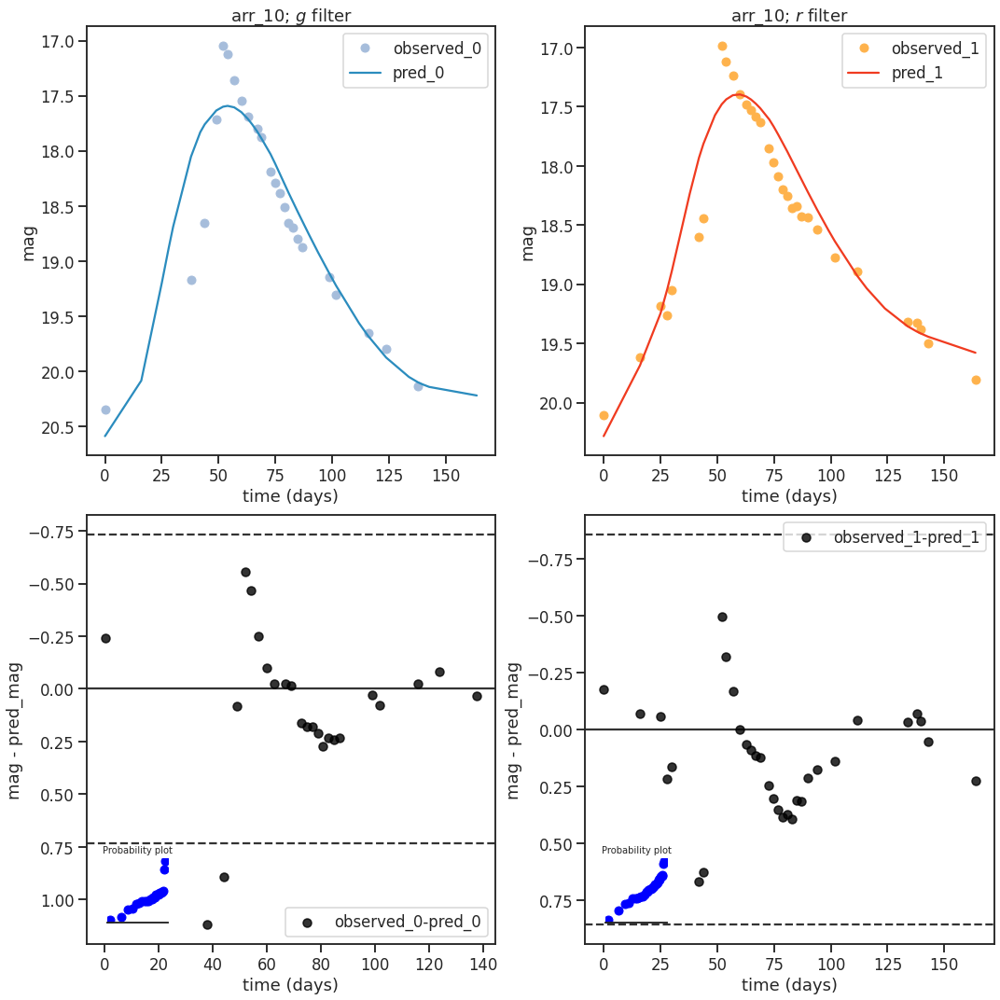

In [23]:
for counter, key in enumerate(decoded_lcs.keys()):
    currObjId = test_objIds[counter]
    currObjId_index = np.where(total_objIds == currObjId)
    currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
    currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']
    if 'custom_sn' not in currCommonFinkclass:
        continue
    plot_lc(df_alerts, currObjId, title_suffix=','.join(currCommonFinkclass))
    plot_decoded_lc(
        decoded_lcs, key, objId=currObjId,
        unnormalize_lcs=True, min_time=min_time, max_time=max_time,
        min_max_mags=min_max_mags
    )
    if counter == 10:
        break

### Observations

About the edges: the starting value of interpolation is the same as the ending value of interpolation. For e.g., if the interpolation starts at a value of 0.04, then it ends at 0.04 as well and then there is a constant value corresponding to the unobserved data.

## Weird case

duration of this light curve (`ZTF22aadesap`) is greater than 1 year (alerts data range used).

In [54]:
plot_lc(df_alerts, 'ZTF22aadesap')

ValueError: No alerts exist for objectId = ZTF22aadesap!

In [55]:
ZTF22aadesap_alerts = df_alerts[df_alerts['objectId'] == 'ZTF22aadesap']
ZTF22aadesap_alerts['jd'].max() - ZTF22aadesap_alerts['jd'].min()

nan